# Dissertation Presentation Notebook

**Cybersecurity Resilience in Algorithmic Trading: An AI-Driven Supervised Anomaly Detection Framework**

This notebook is a presentation companion. It focuses on visual outputs and defendable examples rather than showing the full implementation code.


## Presentation Flow

1. Chapter 1: Aim and research questions
2. Chapter 2: Research gap
3. Chapter 3: Methodology
4. Chapter 4: Results and analysis
5. Chapter 5: Discussion
6. Chapter 6: Conclusion


In [16]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
import plotly.graph_objects as go

ROOT = Path.cwd()
DATA = ROOT / "dissertation_outputs" / "data"
RESULTS = ROOT / "dissertation_outputs" / "results"
FIGURES = ROOT / "dissertation_outputs" / "figures"
FIG3 = FIGURES / "chapter3_visuals"
FIG4 = FIGURES / "chapter4_docx_figures"


# Chapter 1: Introduction

### Aim
Develop an integrated framework for supervised downside-risk prediction, anomaly detection, robustness testing, explainability, and event detection under disturbed market conditions.

### Research Questions
- **RQ1:** Can AI models predict financially significant downside-risk events?
- **RQ2:** Can monitoring and alerting improve identification of unusual behaviour?
- **RQ3:** How robust, explainable, and operationally useful are the models under disturbance?


# Chapter 2: Literature Review and Research Gap


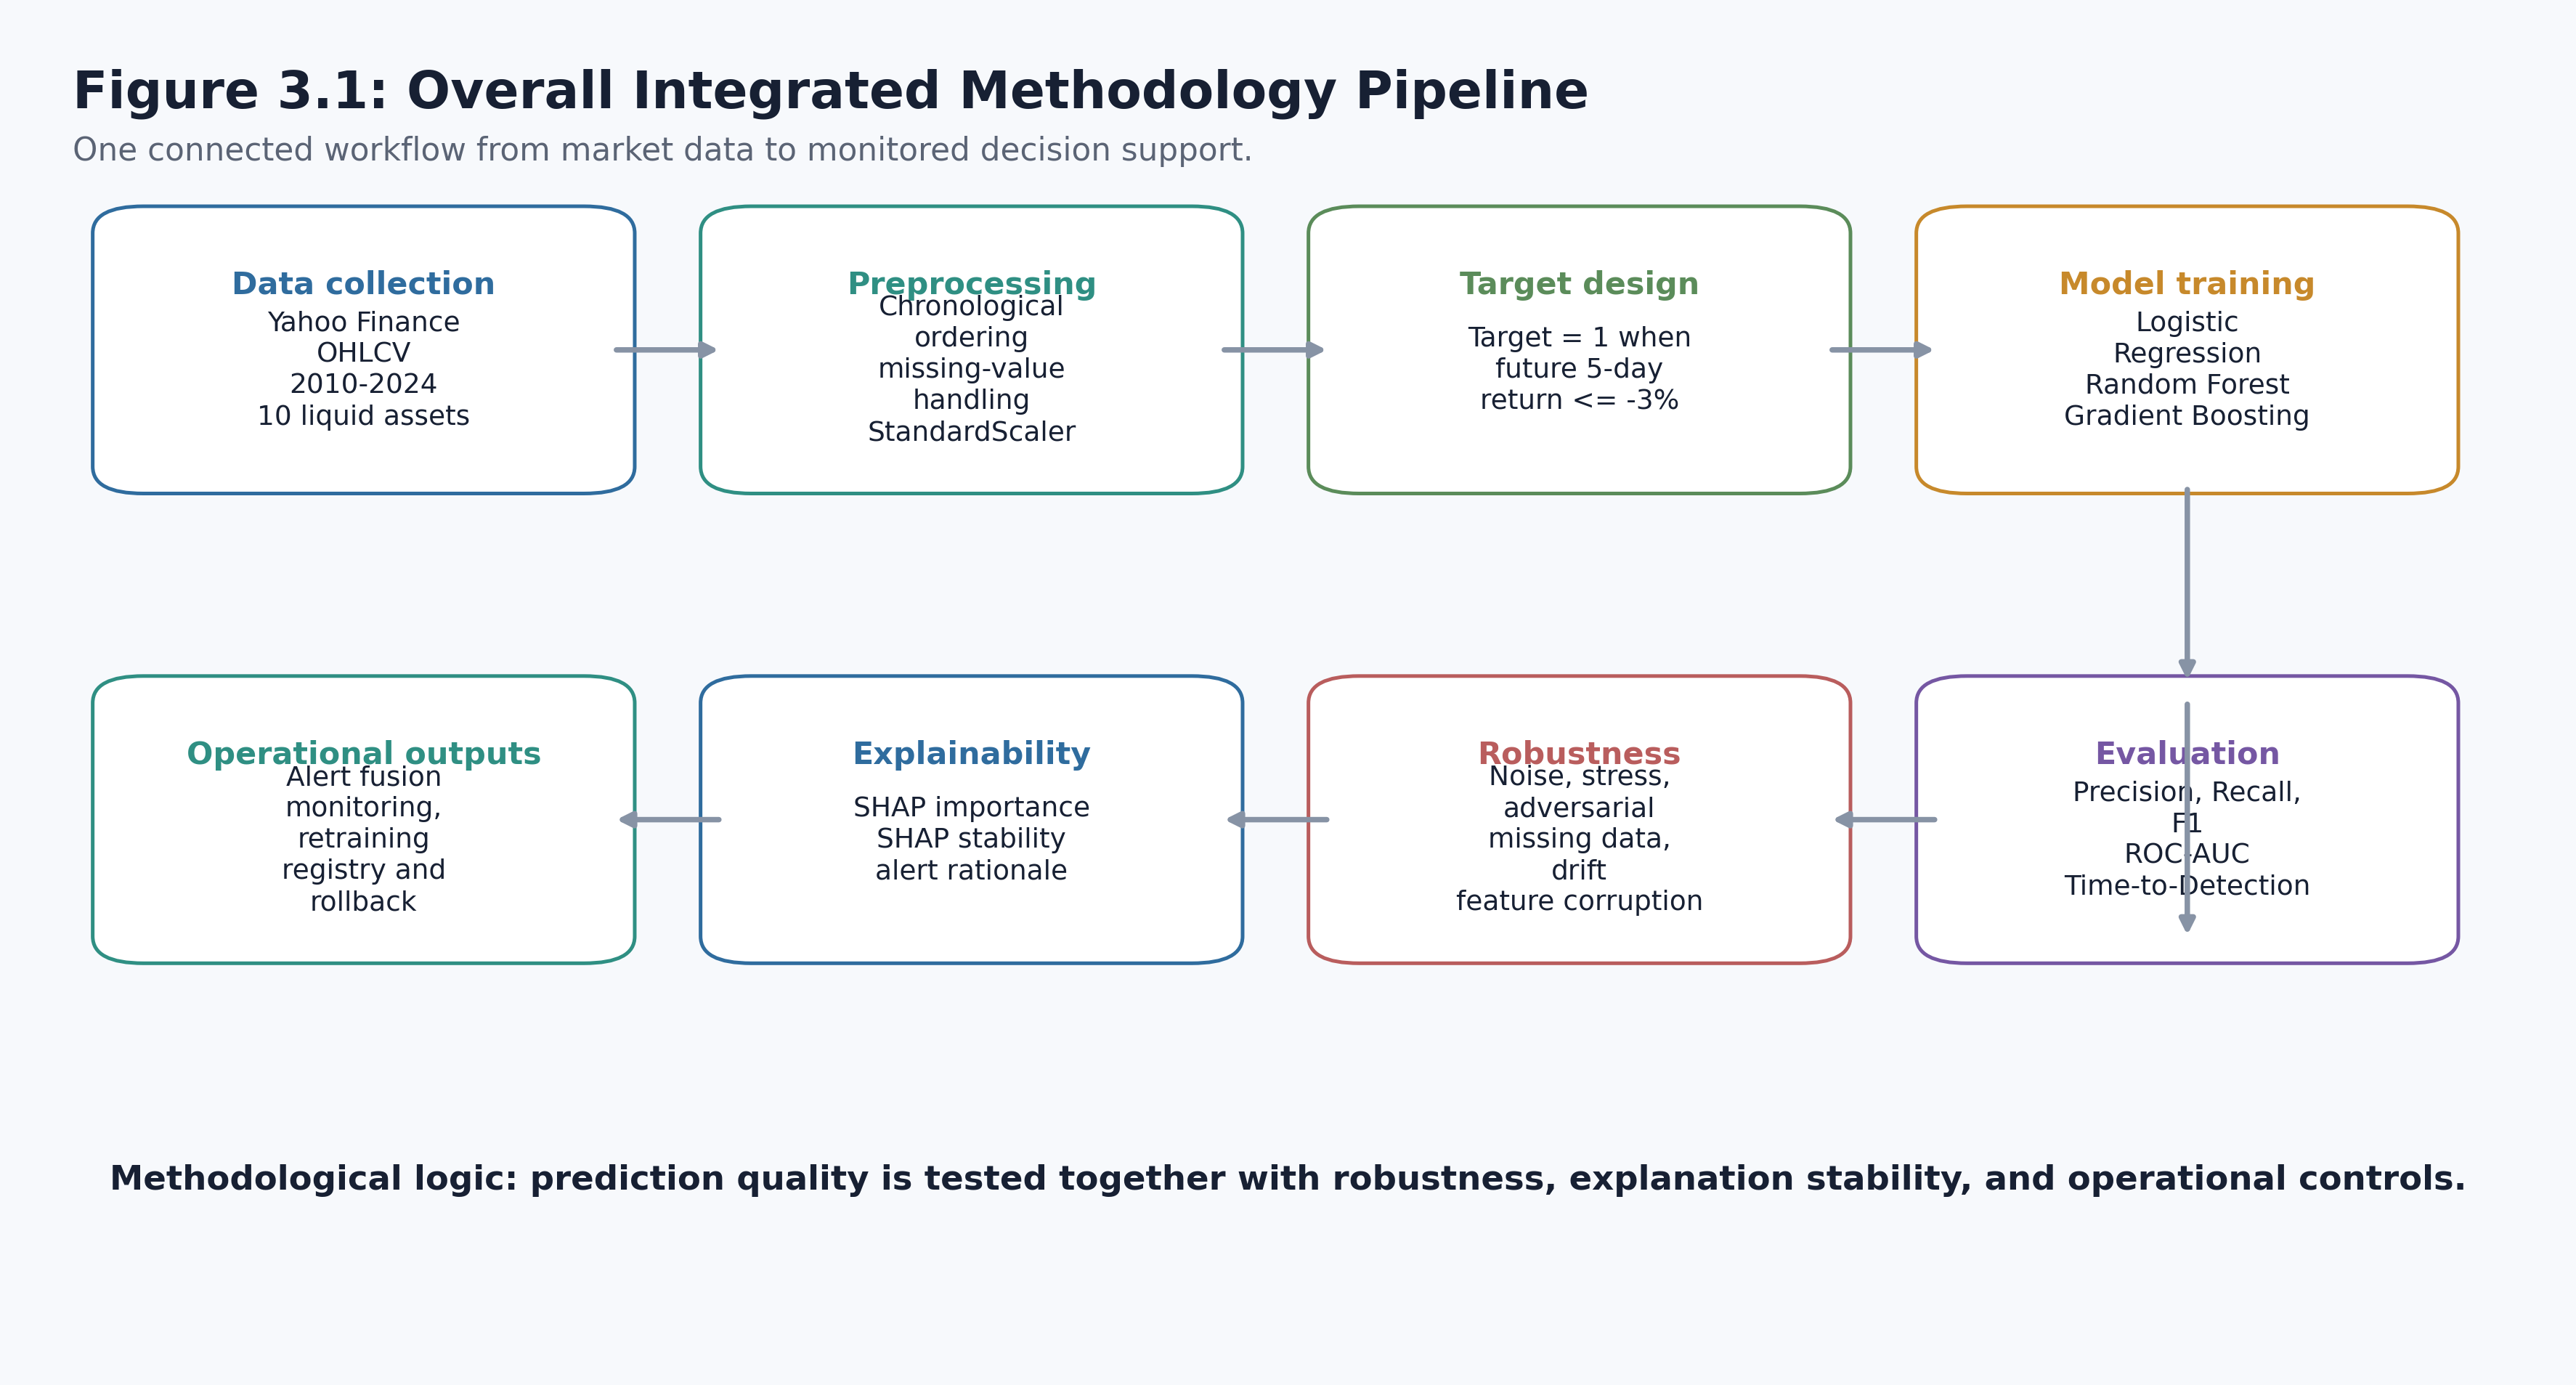

In [17]:
display(Image(filename=str(FIG3 / "figure_3_1_integrated_methodology_pipeline.png")))


# Chapter 3: Research Methodology


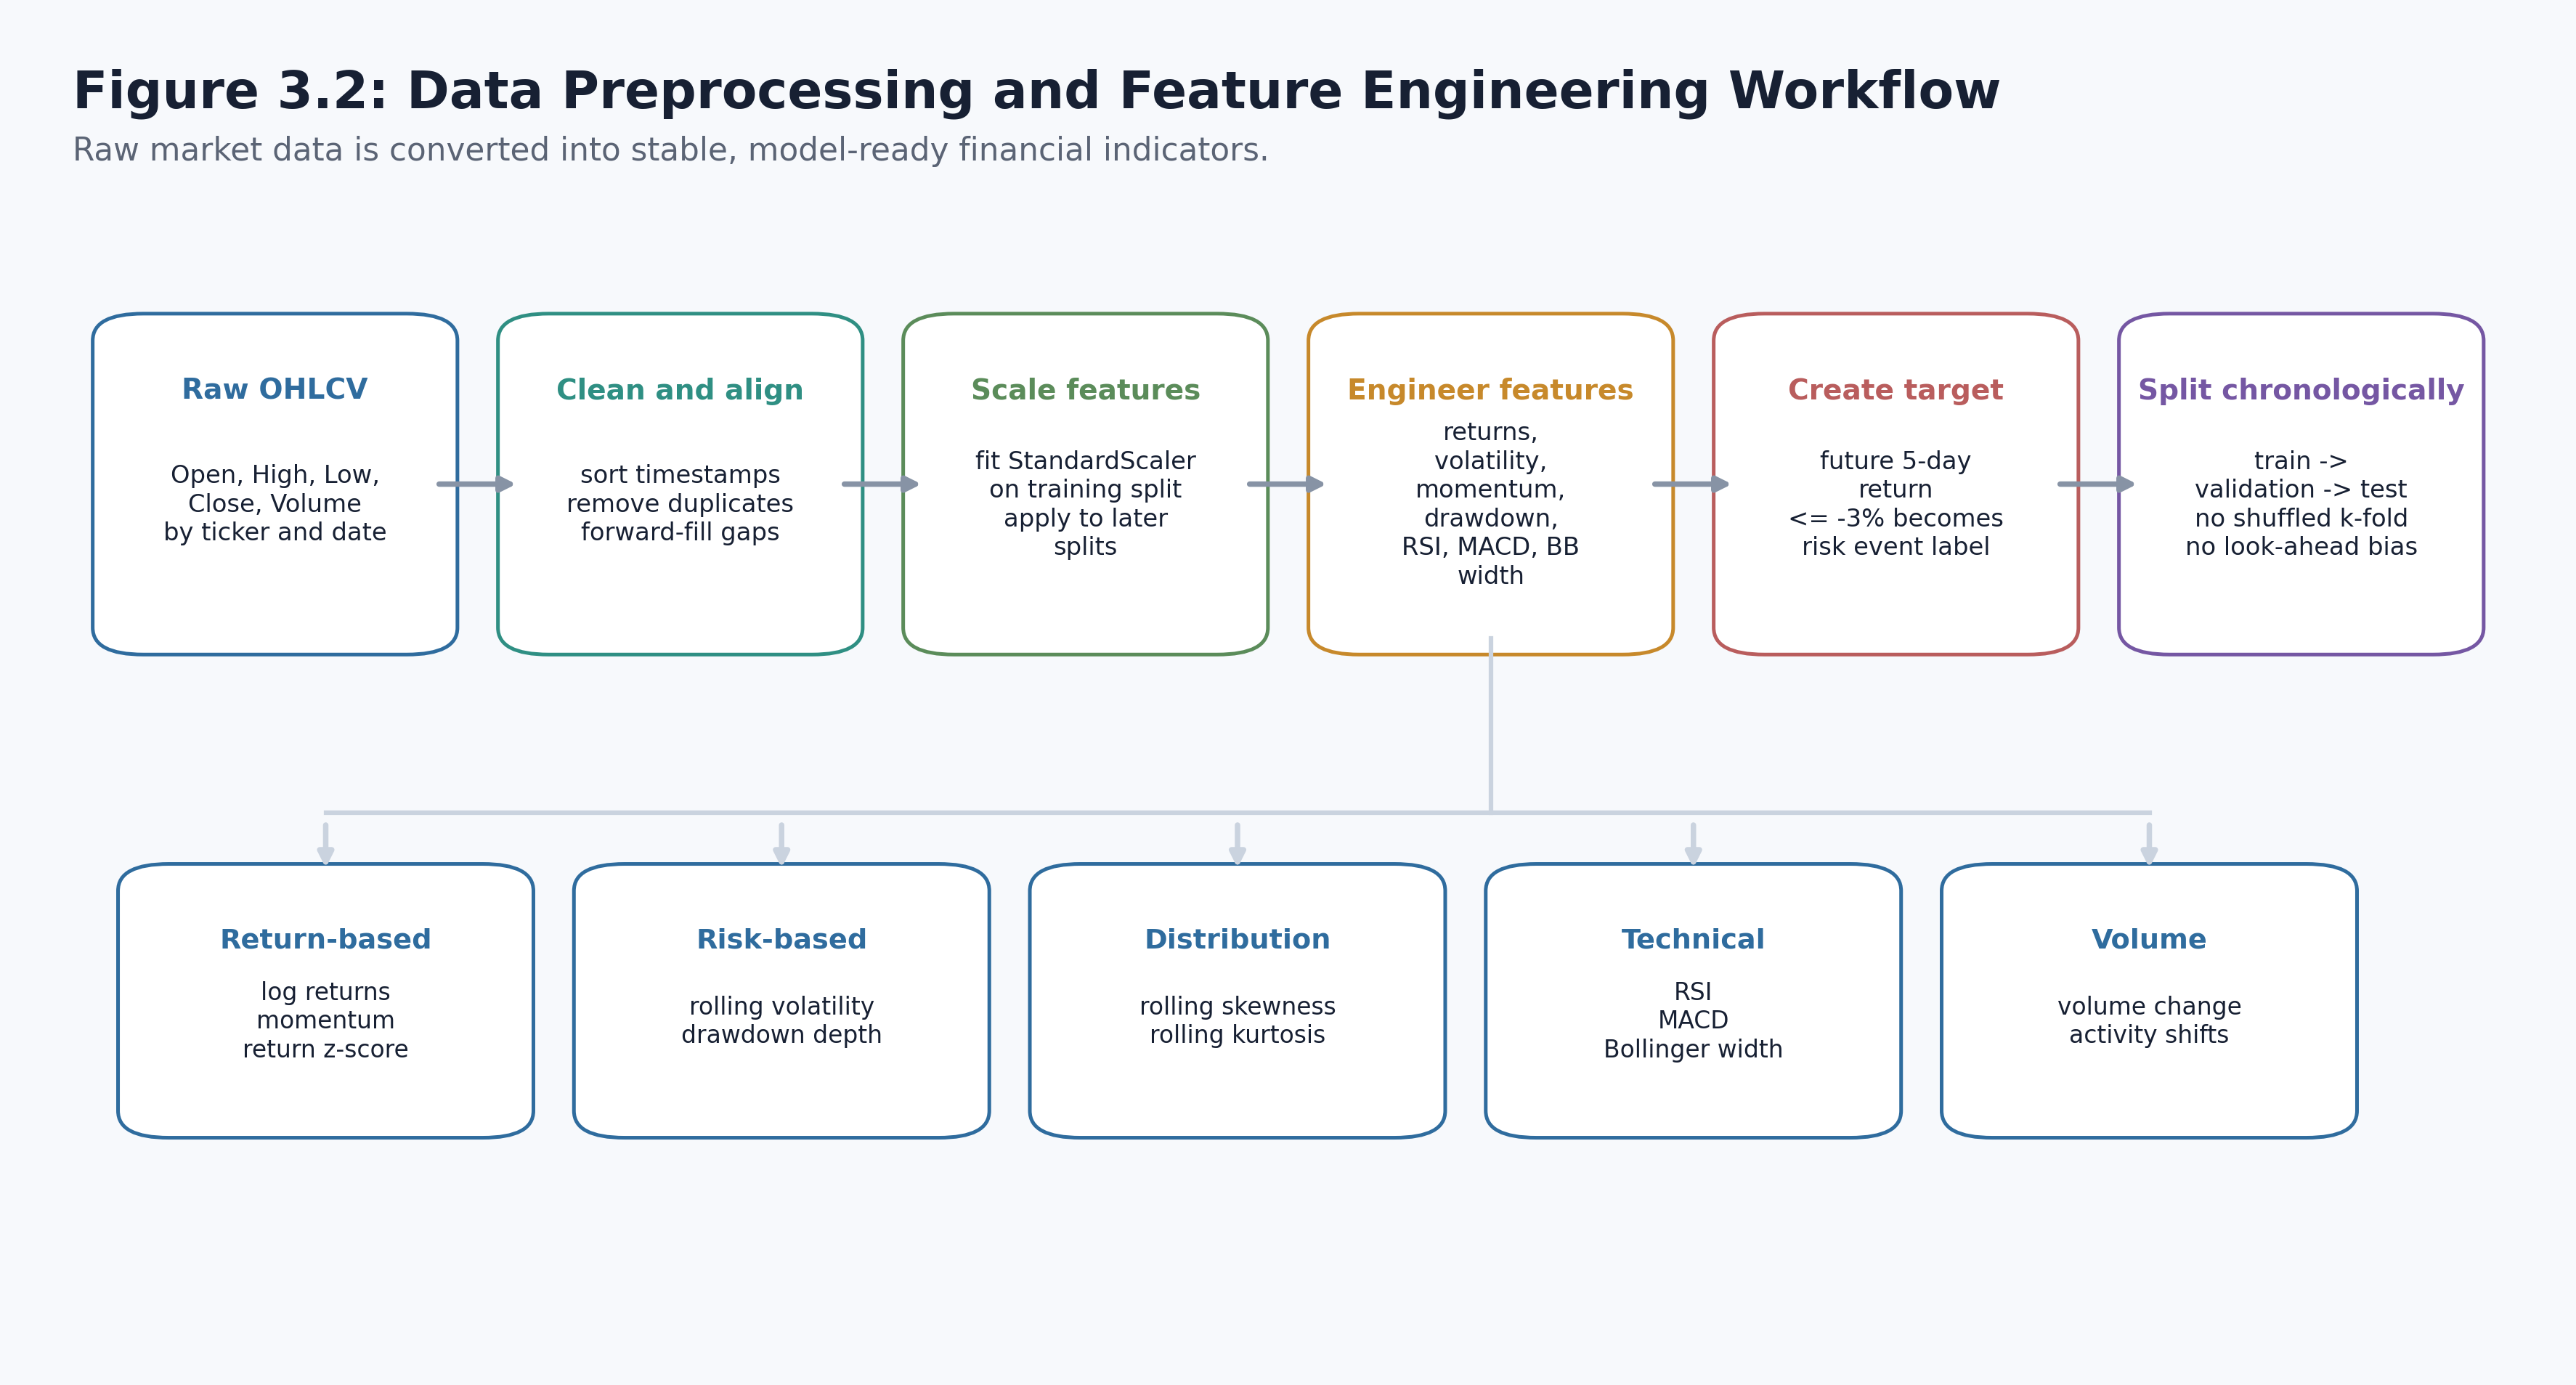

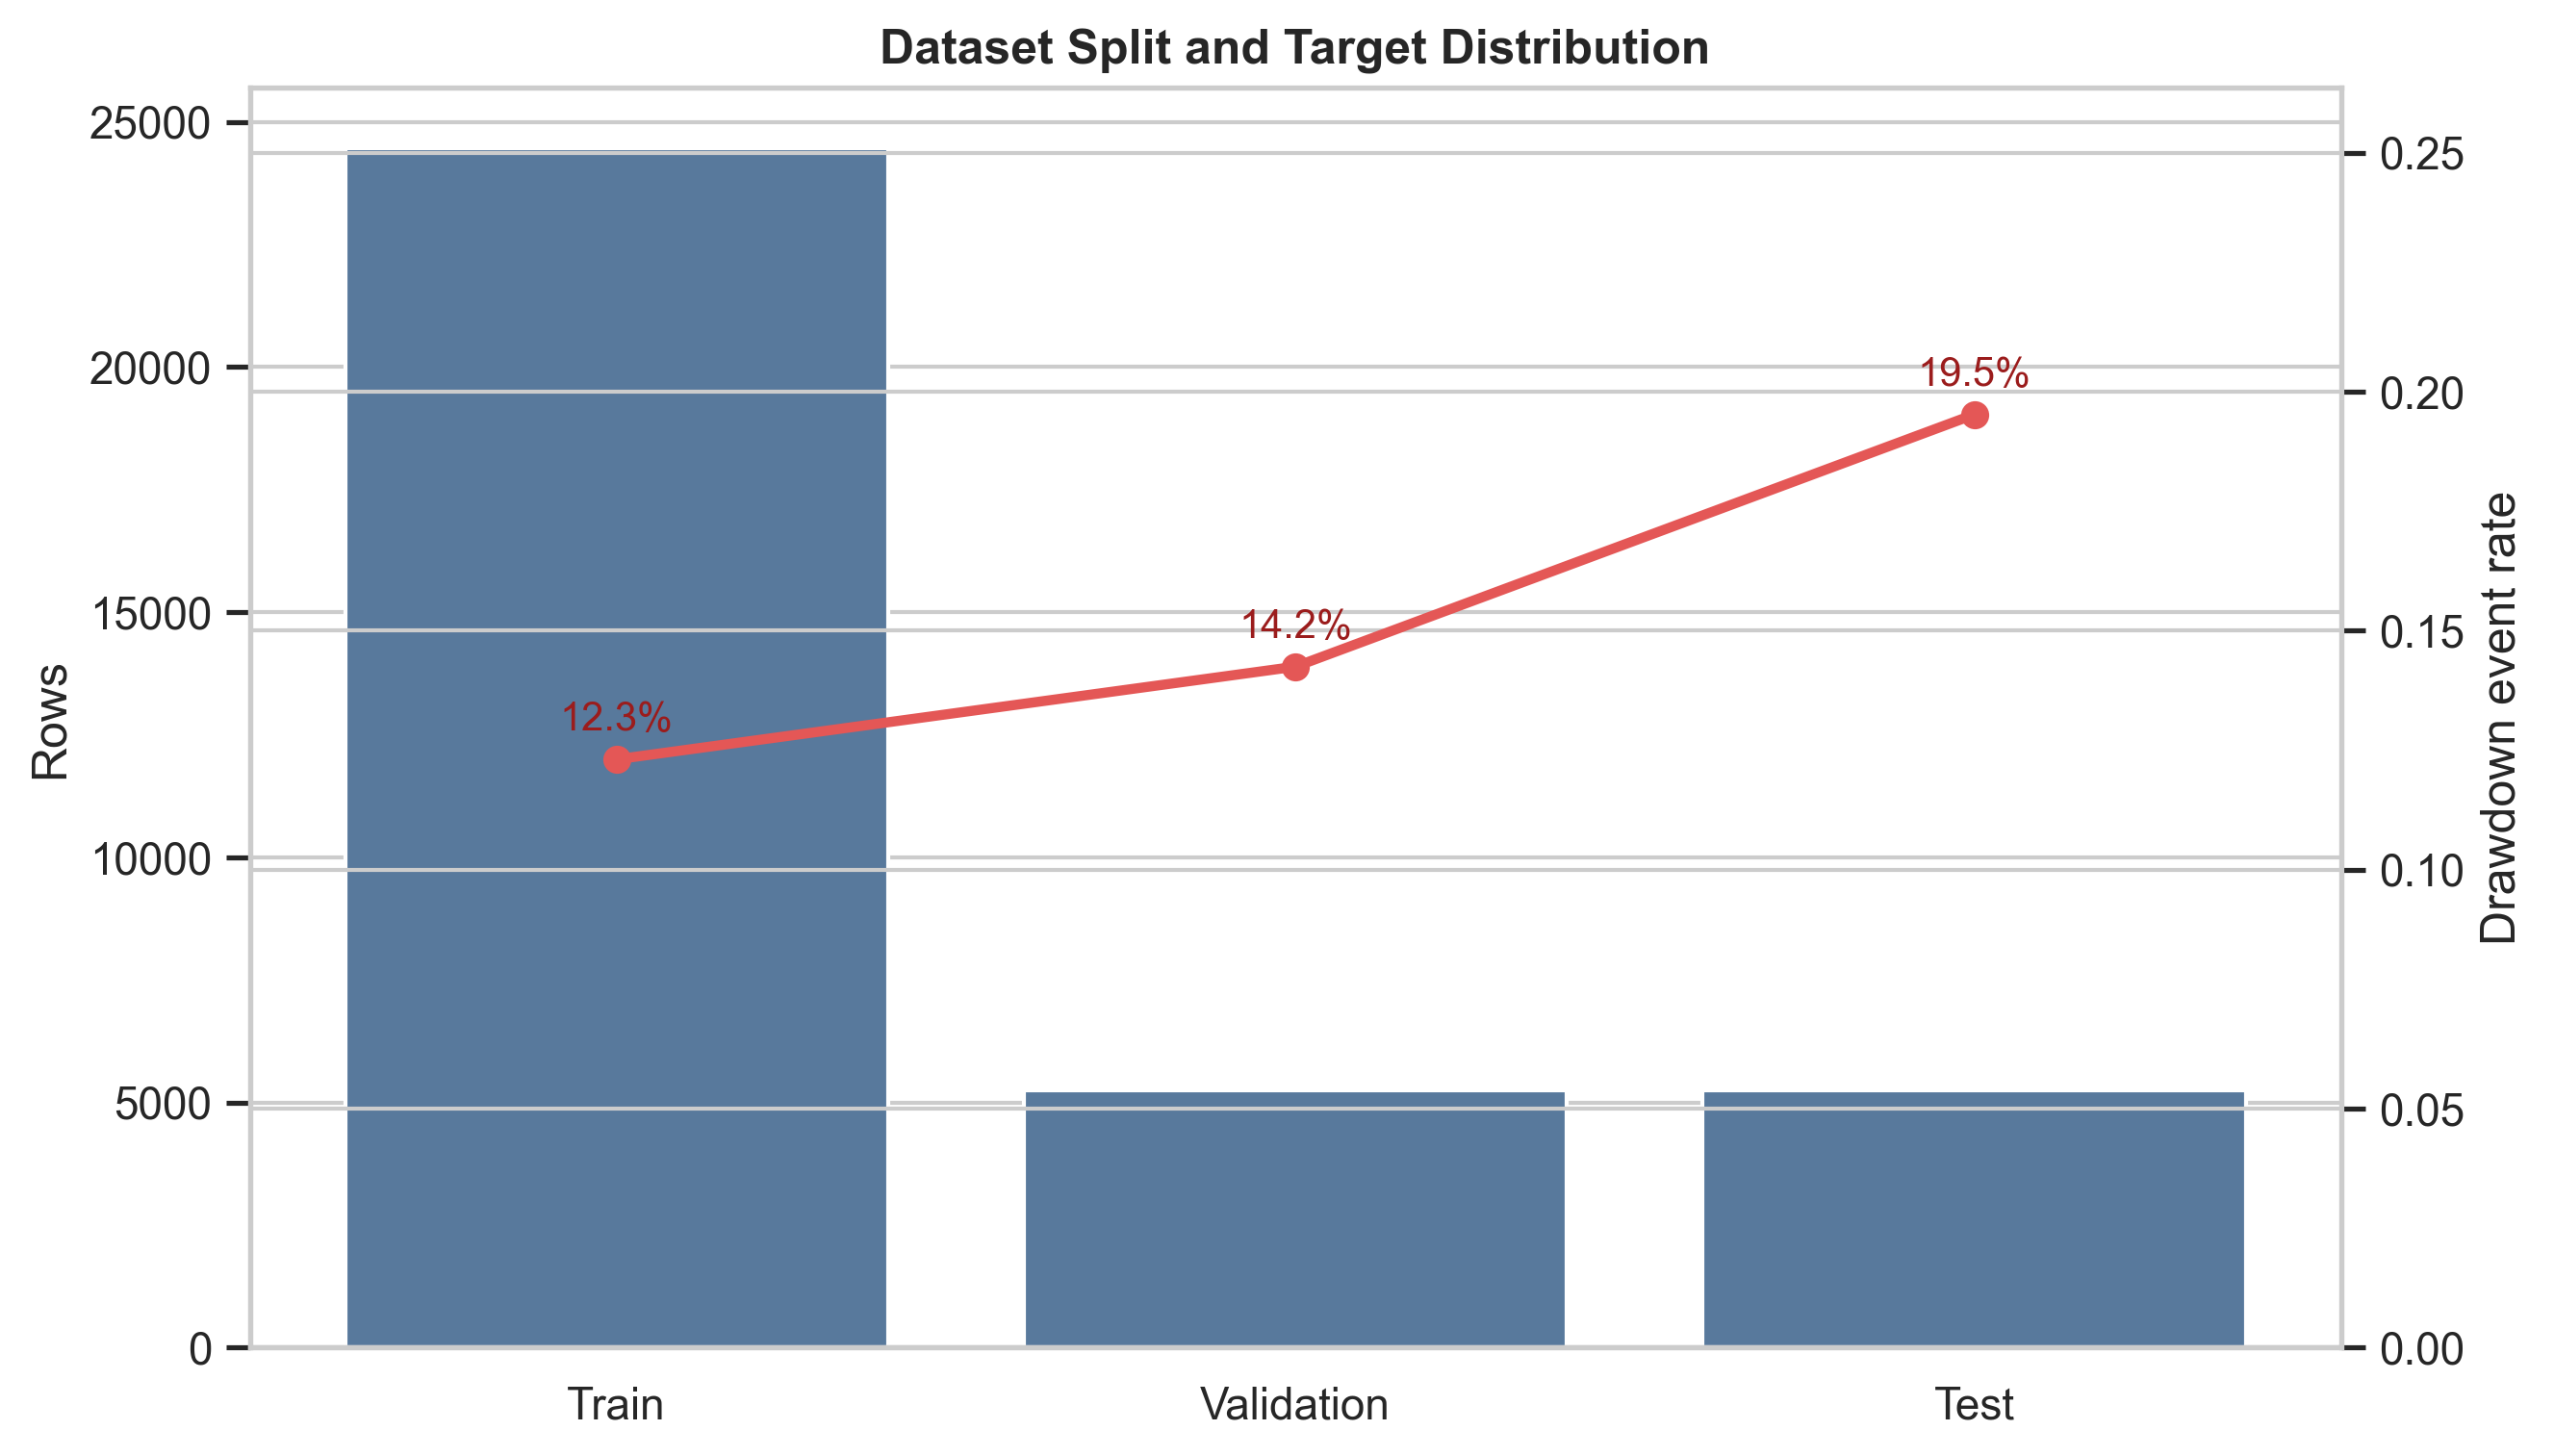

In [18]:
display(Image(filename=str(FIG3 / "figure_3_2_preprocessing_feature_engineering_workflow.png")))
display(Image(filename=str(FIG4 / "figure_4_3_dataset_split_target_distribution.png")))


In [19]:
split_summary = pd.read_csv(RESULTS / "time_series_split_summary.csv")
split_summary


,Split,Rows,Assets,Start_Date,End_Date,Drawdown_Events,Event_Rate
0,Test,5250,10,2021-11-19,2023-12-21,1025,0.195238
1,Train,24470,10,2010-02-02,2019-10-21,3012,0.123089
2,Validation,5250,10,2019-10-22,2021-11-18,748,0.142476


## Chapter 3 Example: What the Model Predicts

A row is labelled `Target = 1` when the future 5-day return is `-3%` or worse. The alerting system then learns patterns in today's features that are associated with that future event.


In [20]:
pd.DataFrame([
    {"Today Close": 100, "Close After 5 Days": 96, "Future Return": "-4%", "Target": 1},
    {"Today Close": 100, "Close After 5 Days": 99, "Future Return": "-1%", "Target": 0},
])


,Today Close,Close After 5 Days,Future Return,Target
0,100,96,-4%,1
1,100,99,-1%,0


# Chapter 4: Results and Analysis


## Baseline supervised model performance


In [21]:
metrics = pd.read_csv(RESULTS / "supervised_model_metrics.csv")
metrics[metrics["Split"].eq("Test")]


,Model,Split,Accuracy,Precision,Recall,F1_Score,ROC_AUC,TN,FP,FN,TP,Predicted_Events,True_Events
3,Logistic Regression,Test,0.477714,0.235439,0.745366,0.357845,0.611638,1744,2481,261,764,3245,1025
4,Random Forest,Test,0.805143,0.600000,0.005854,0.011594,0.548777,4221,4,1019,6,10,1025
5,Gradient Boosting Fallback,Test,0.776762,0.230769,0.061463,0.097072,0.544465,4015,210,962,63,273,1025


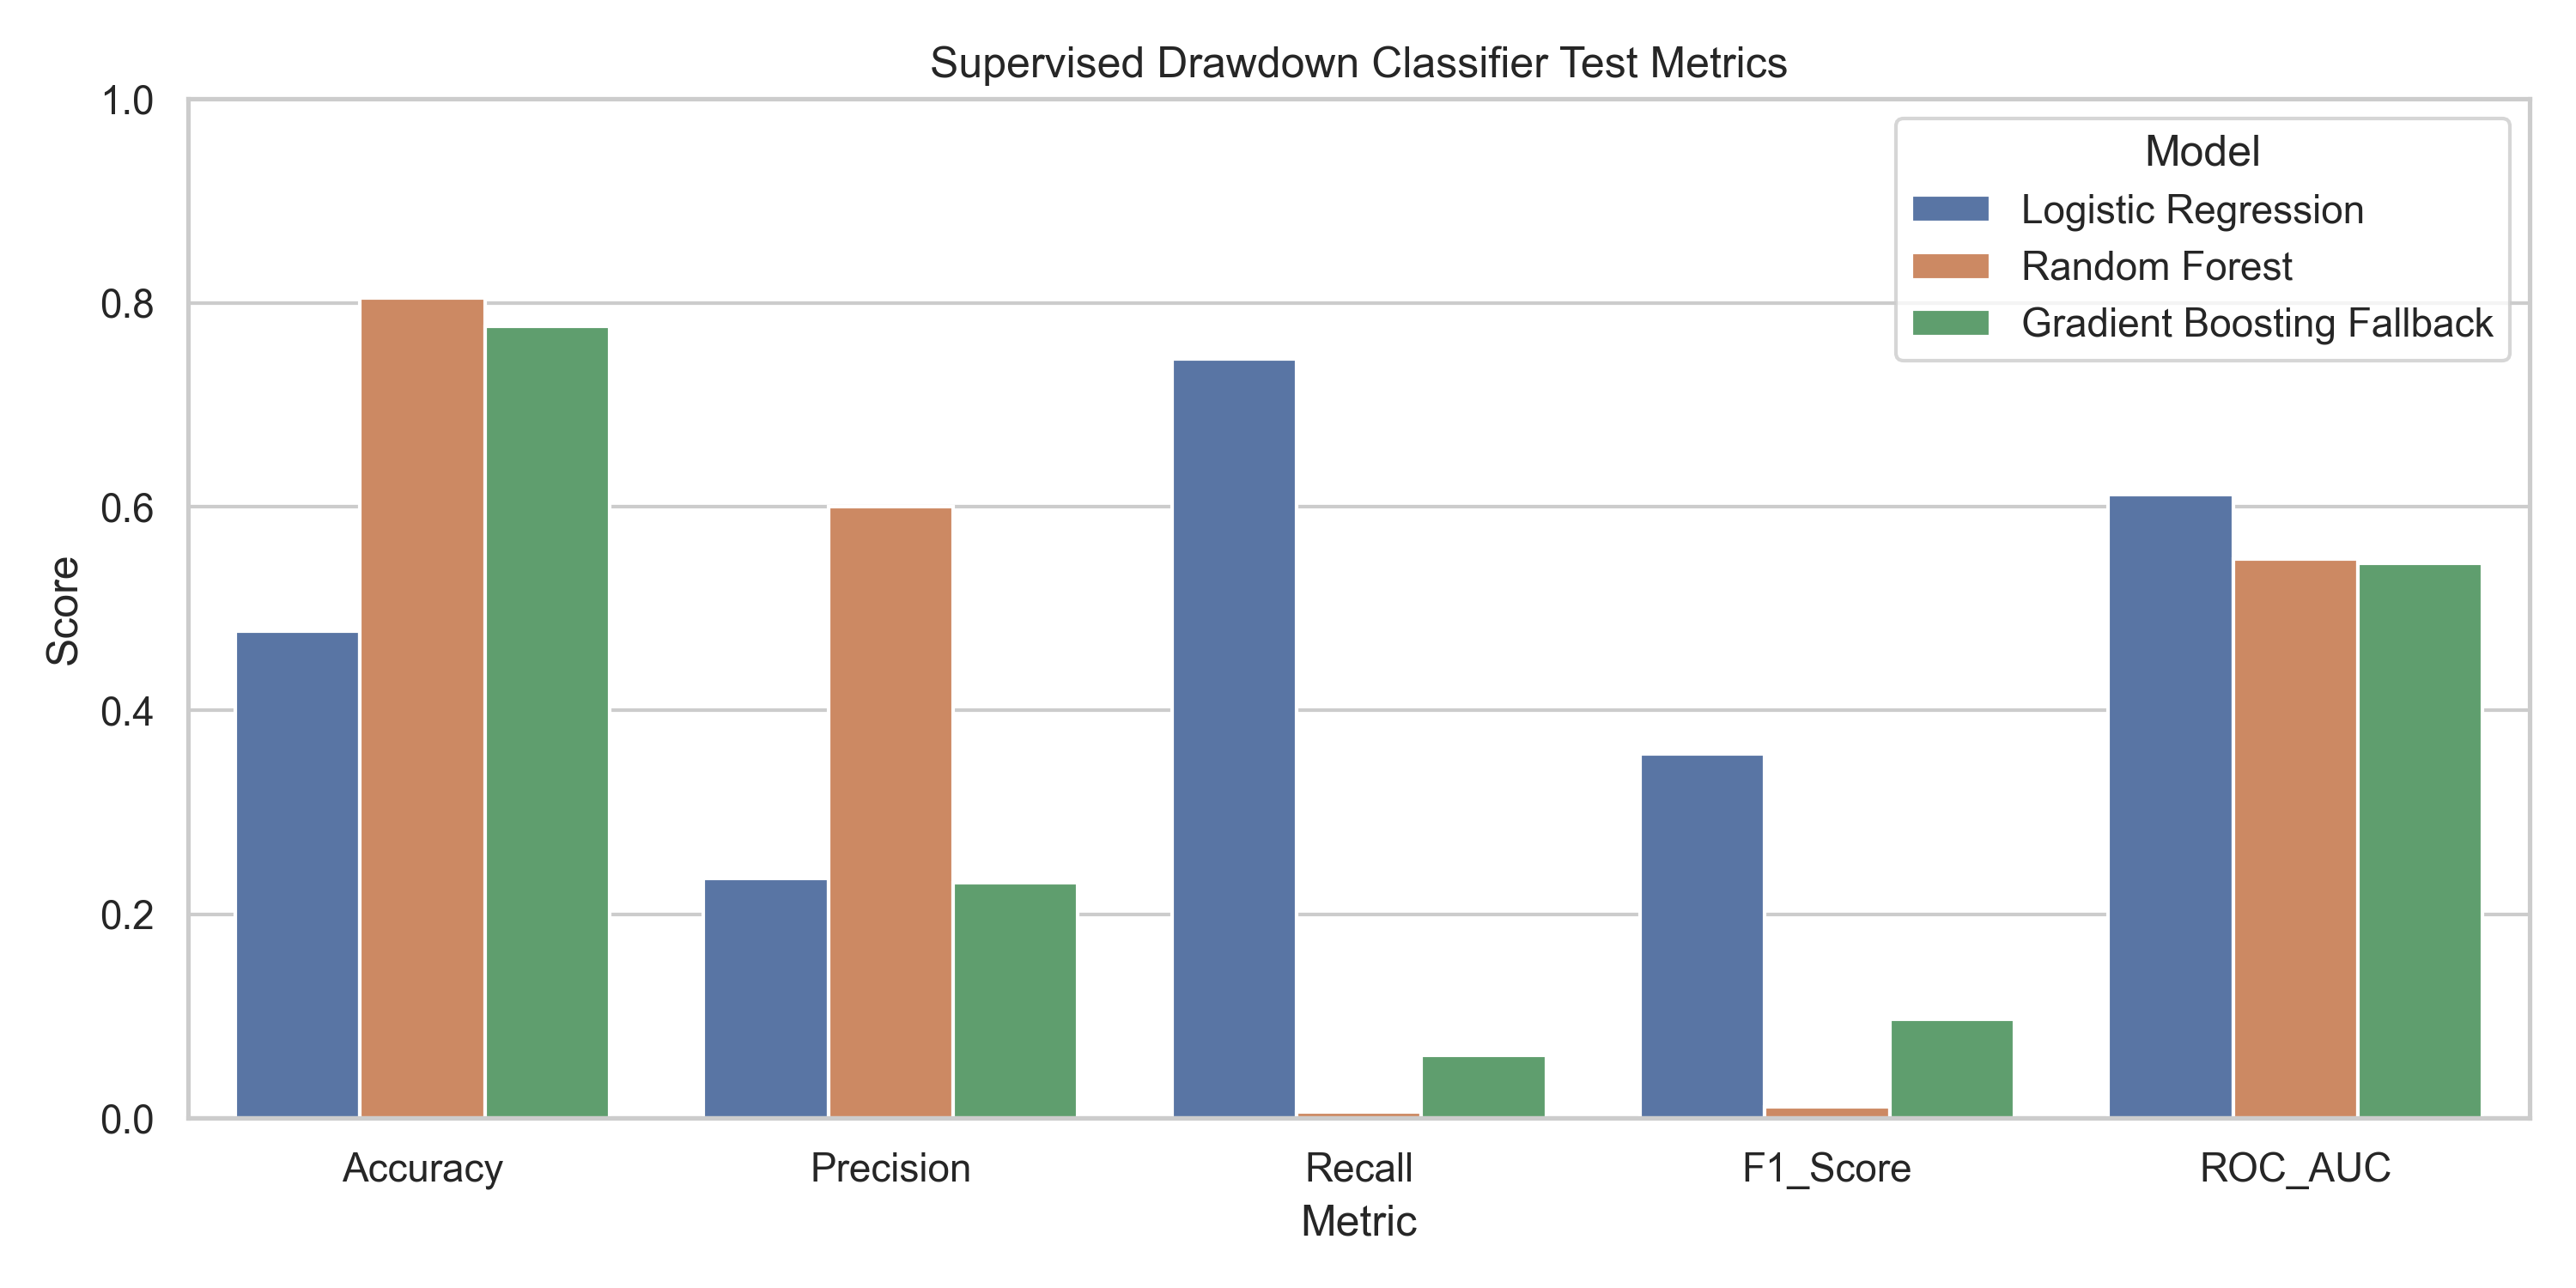

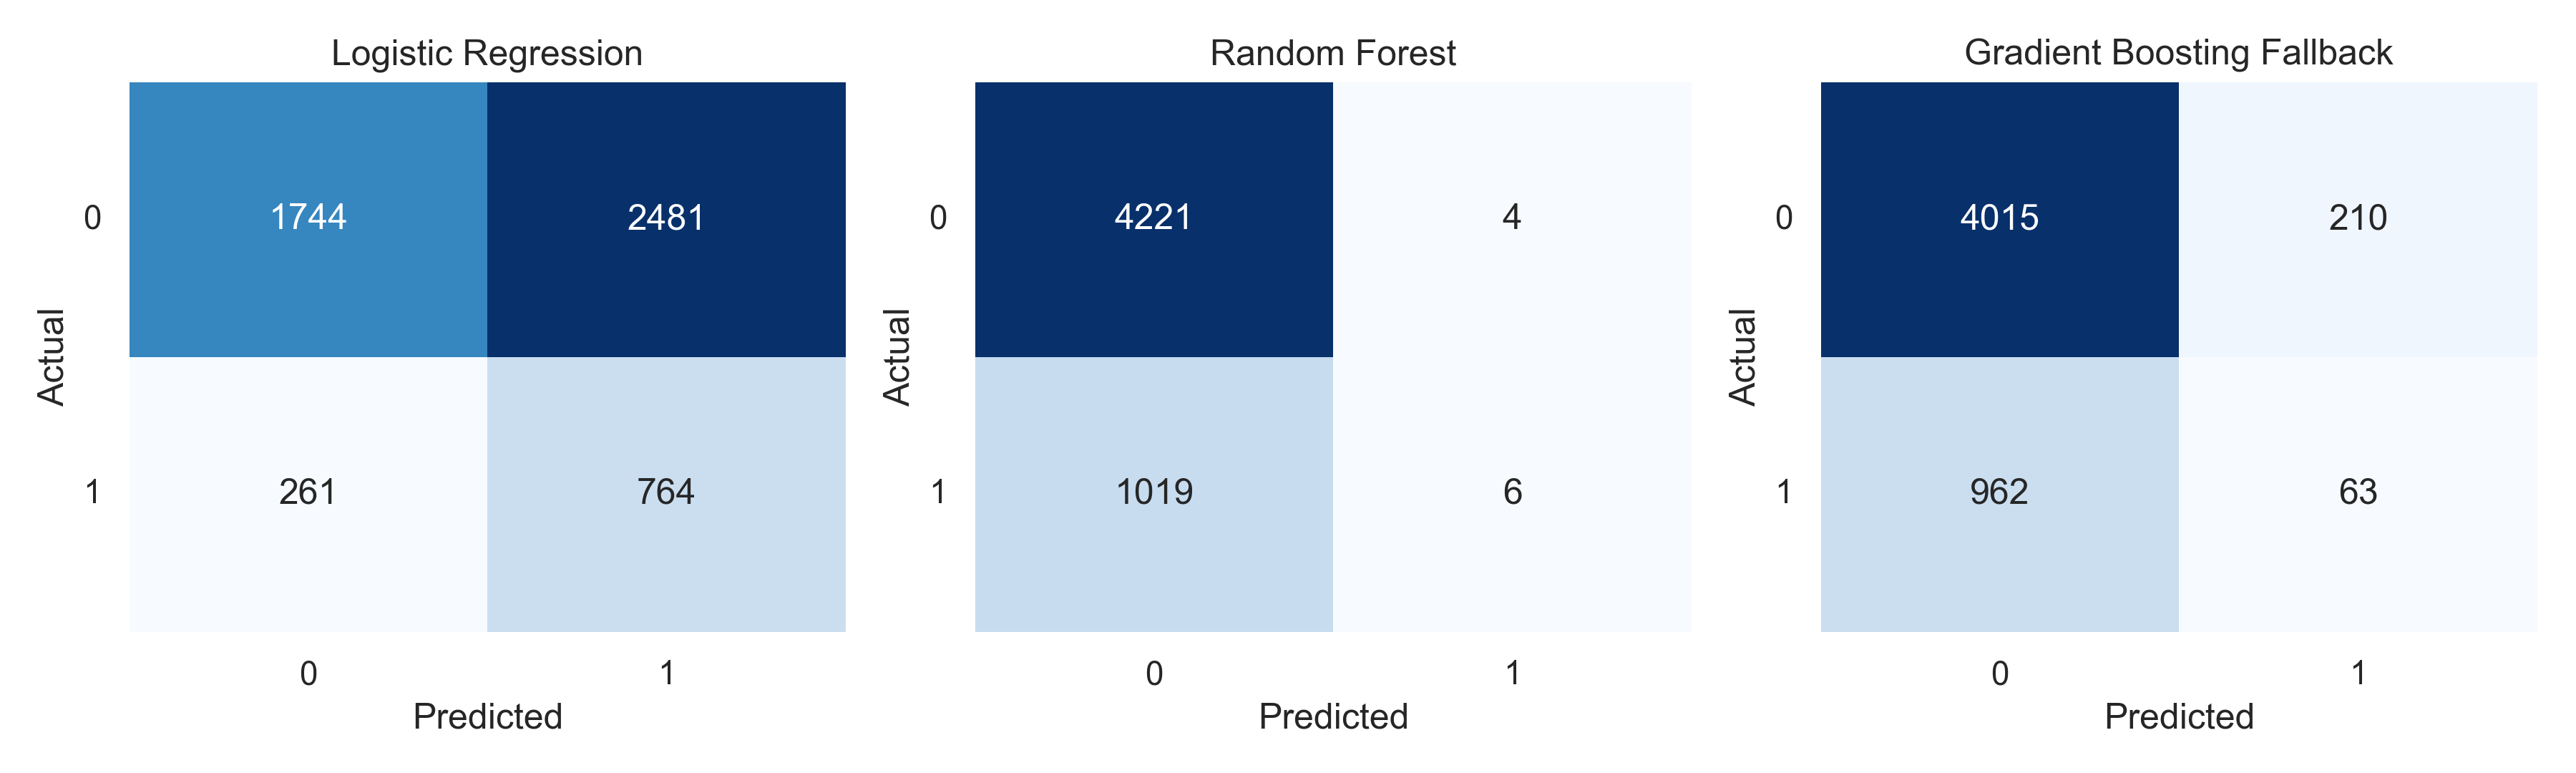

In [22]:
display(Image(filename=str(FIGURES / "supervised_model_test_metrics.png")))
display(Image(filename=str(FIGURES / "confusion_matrix_heatmaps_supervised.png")))


## Visible Alert Examples

The system does not only produce aggregate metrics. It also creates row-level alert flags that an analyst can inspect.


In [23]:
audit = pd.read_csv(RESULTS / "investigator_alert_rationale_audit.csv", parse_dates=["Date"])
top_alerts = (
    audit[audit["Severity"].eq("Critical")]
    .sort_values("Fusion_Risk_Score", ascending=False)
    [["Date", "Ticker", "Severity", "Fusion_Risk_Score", "Supervised_Alert_Count", "Event_Detector_Alert_Count", "Top_Feature_Deviations"]]
    .head(10)
    .copy()
)
top_alerts["Fusion_Risk_Score"] = top_alerts["Fusion_Risk_Score"].round(3)
top_alerts


,Date,Ticker,Severity,Fusion_Risk_Score,Supervised_Alert_Count,Event_Detector_Alert_Count,Top_Feature_Deviations
0,2023-01-20,NVDA,Critical,0.988,2,3,Return=4.04z; BB_Width=3.82z; MA_Ratio_20=3.56z
1,2023-01-23,NVDA,Critical,0.982,3,3,MA_Ratio_20=5.62z; MA_Ratio_10=4.95z; Return=4...
2,2023-02-02,SPY,Critical,0.972,1,2,Momentum_10=7.44z; MACD=4.19z; MACD_Signal=2.91z
3,2023-03-31,GS,Critical,0.972,1,2,MACD_Signal=8.53z; MACD=6.31z; Momentum_10=6.23z
4,2023-01-24,NVDA,Critical,0.969,2,3,BB_Width=5.37z; MA_Ratio_20=5.34z; MA_Ratio_10...
5,2022-01-28,QQQ,Critical,0.968,2,3,MACD=9.35z; MACD_Signal=7.47z; Momentum_10=6.94z
6,2022-05-17,NVDA,Critical,0.968,1,3,Volatility_10=5.84z; Volatility_20=5.38z; BB_W...
7,2022-05-18,NVDA,Critical,0.966,1,2,Volatility_10=5.94z; Volatility_20=5.57z; Retu...
8,2022-05-26,NVDA,Critical,0.964,1,3,Volatility_20=5.29z; Volatility_10=4.80z; Draw...
9,2022-05-25,NVDA,Critical,0.964,1,3,Volatility_20=5.49z; Volatility_10=4.69z; Draw...


In [24]:
price_df = pd.read_csv(DATA / "supervised_drawdown_dataset.csv", parse_dates=["Date"])
critical_alerts = audit[audit["Severity"].eq("Critical")].copy()
flagged_tickers = critical_alerts["Ticker"].value_counts().index.tolist()
all_tickers = price_df["Ticker"].drop_duplicates().tolist()
tickers = flagged_tickers + [ticker for ticker in all_tickers if ticker not in flagged_tickers]
default_ticker = "NVDA" if "NVDA" in tickers else tickers[0]
fig = go.Figure()
trace_groups = []
for ticker in tickers:
    asset = price_df[price_df["Ticker"].eq(ticker)].sort_values("Date")
    flags = critical_alerts[critical_alerts["Ticker"].eq(ticker)].sort_values("Date")
    visible = ticker == default_ticker
    start = len(fig.data)
    fig.add_trace(go.Scatter(x=asset["Date"], y=asset["Close"], mode="lines", name=f"{ticker} Close", visible=visible, line=dict(color="#1f5a7a", width=2), hovertemplate="Date: %{x|%Y-%m-%d}<br>Close: %{y:.2f}<extra></extra>"))
    if not flags.empty:
        marked = flags.merge(asset[["Date", "Close"]], on="Date", how="left")
        hover = ["<br>".join([f"Ticker: {r.Ticker}", f"Severity: {r.Severity}", f"Risk score: {r.Fusion_Risk_Score:.3f}", f"Feature deviations: {r.Top_Feature_Deviations}", f"Logistic drivers: {r.Top_Logistic_Drivers}"]) for r in marked.itertuples()]
        fig.add_trace(go.Scatter(x=marked["Date"], y=marked["Close"], mode="markers", name="Critical alert", visible=visible, marker=dict(color="#c83e4d", size=11, symbol="diamond", line=dict(color="white", width=1)), text=hover, hovertemplate="Date: %{x|%Y-%m-%d}<br>Close: %{y:.2f}<br>%{text}<extra></extra>"))
    else:
        mid = asset.iloc[len(asset)//2]
        fig.add_trace(go.Scatter(x=[mid["Date"]], y=[mid["Close"]], mode="text", text=["No critical alerts in audit sample"], visible=visible, showlegend=False, hoverinfo="skip"))
    trace_groups.append((ticker, start, len(fig.data)))
buttons=[]
for ticker,start,end in trace_groups:
    visible=[False]*len(fig.data)
    for i in range(start,end): visible[i]=True
    buttons.append(dict(label=ticker, method="update", args=[{"visible":visible},{"title":f"Critical Alert Flags on Stock Price: {ticker}"}]))
fig.update_layout(title=f"Critical Alert Flags on Stock Price: {default_ticker}", xaxis_title="Date", yaxis_title="Close Price", template="plotly_white", height=560, updatemenus=[dict(buttons=buttons, direction="down", x=0, y=1.15)], annotations=[dict(text="Select ticker", x=0, y=1.22, xref="paper", yref="paper", showarrow=False)])
fig.show()


## Alert fusion


In [25]:
fusion = pd.read_csv(RESULTS / "unified_alert_fusion_metrics.csv")
fusion


,Policy,Split,Precision,Recall,F1_Score,Predicted_Alerts
0,Fusion_OR_Alert,Test,0.208148,0.957073,0.341931,4713
1,Fusion_Consensus_Alert,Test,0.234342,0.748293,0.356910,3273
2,Fusion_OR_Alert,Validation,0.157440,0.950535,0.270137,4516
3,Fusion_Consensus_Alert,Validation,0.188502,0.723262,0.299060,2870


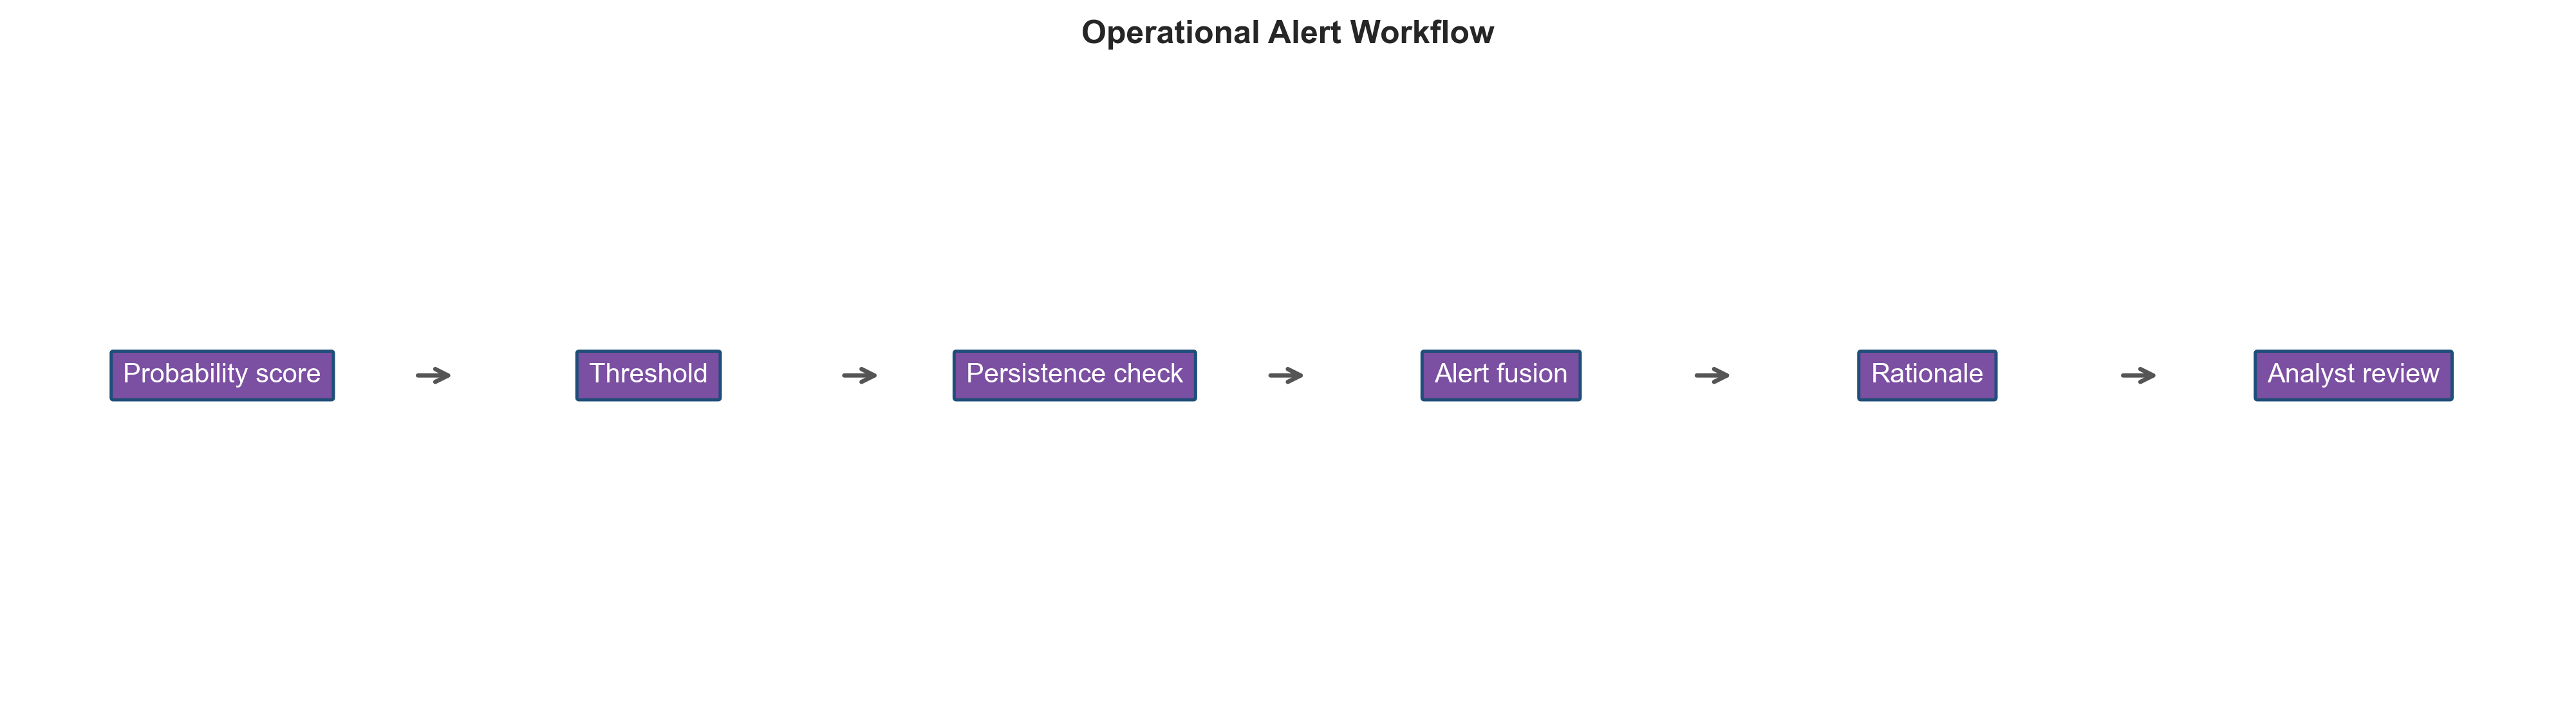

In [26]:
display(Image(filename=str(FIG4 / "figure_4_8_operational_alert_workflow.png")))


## Robustness and stress testing


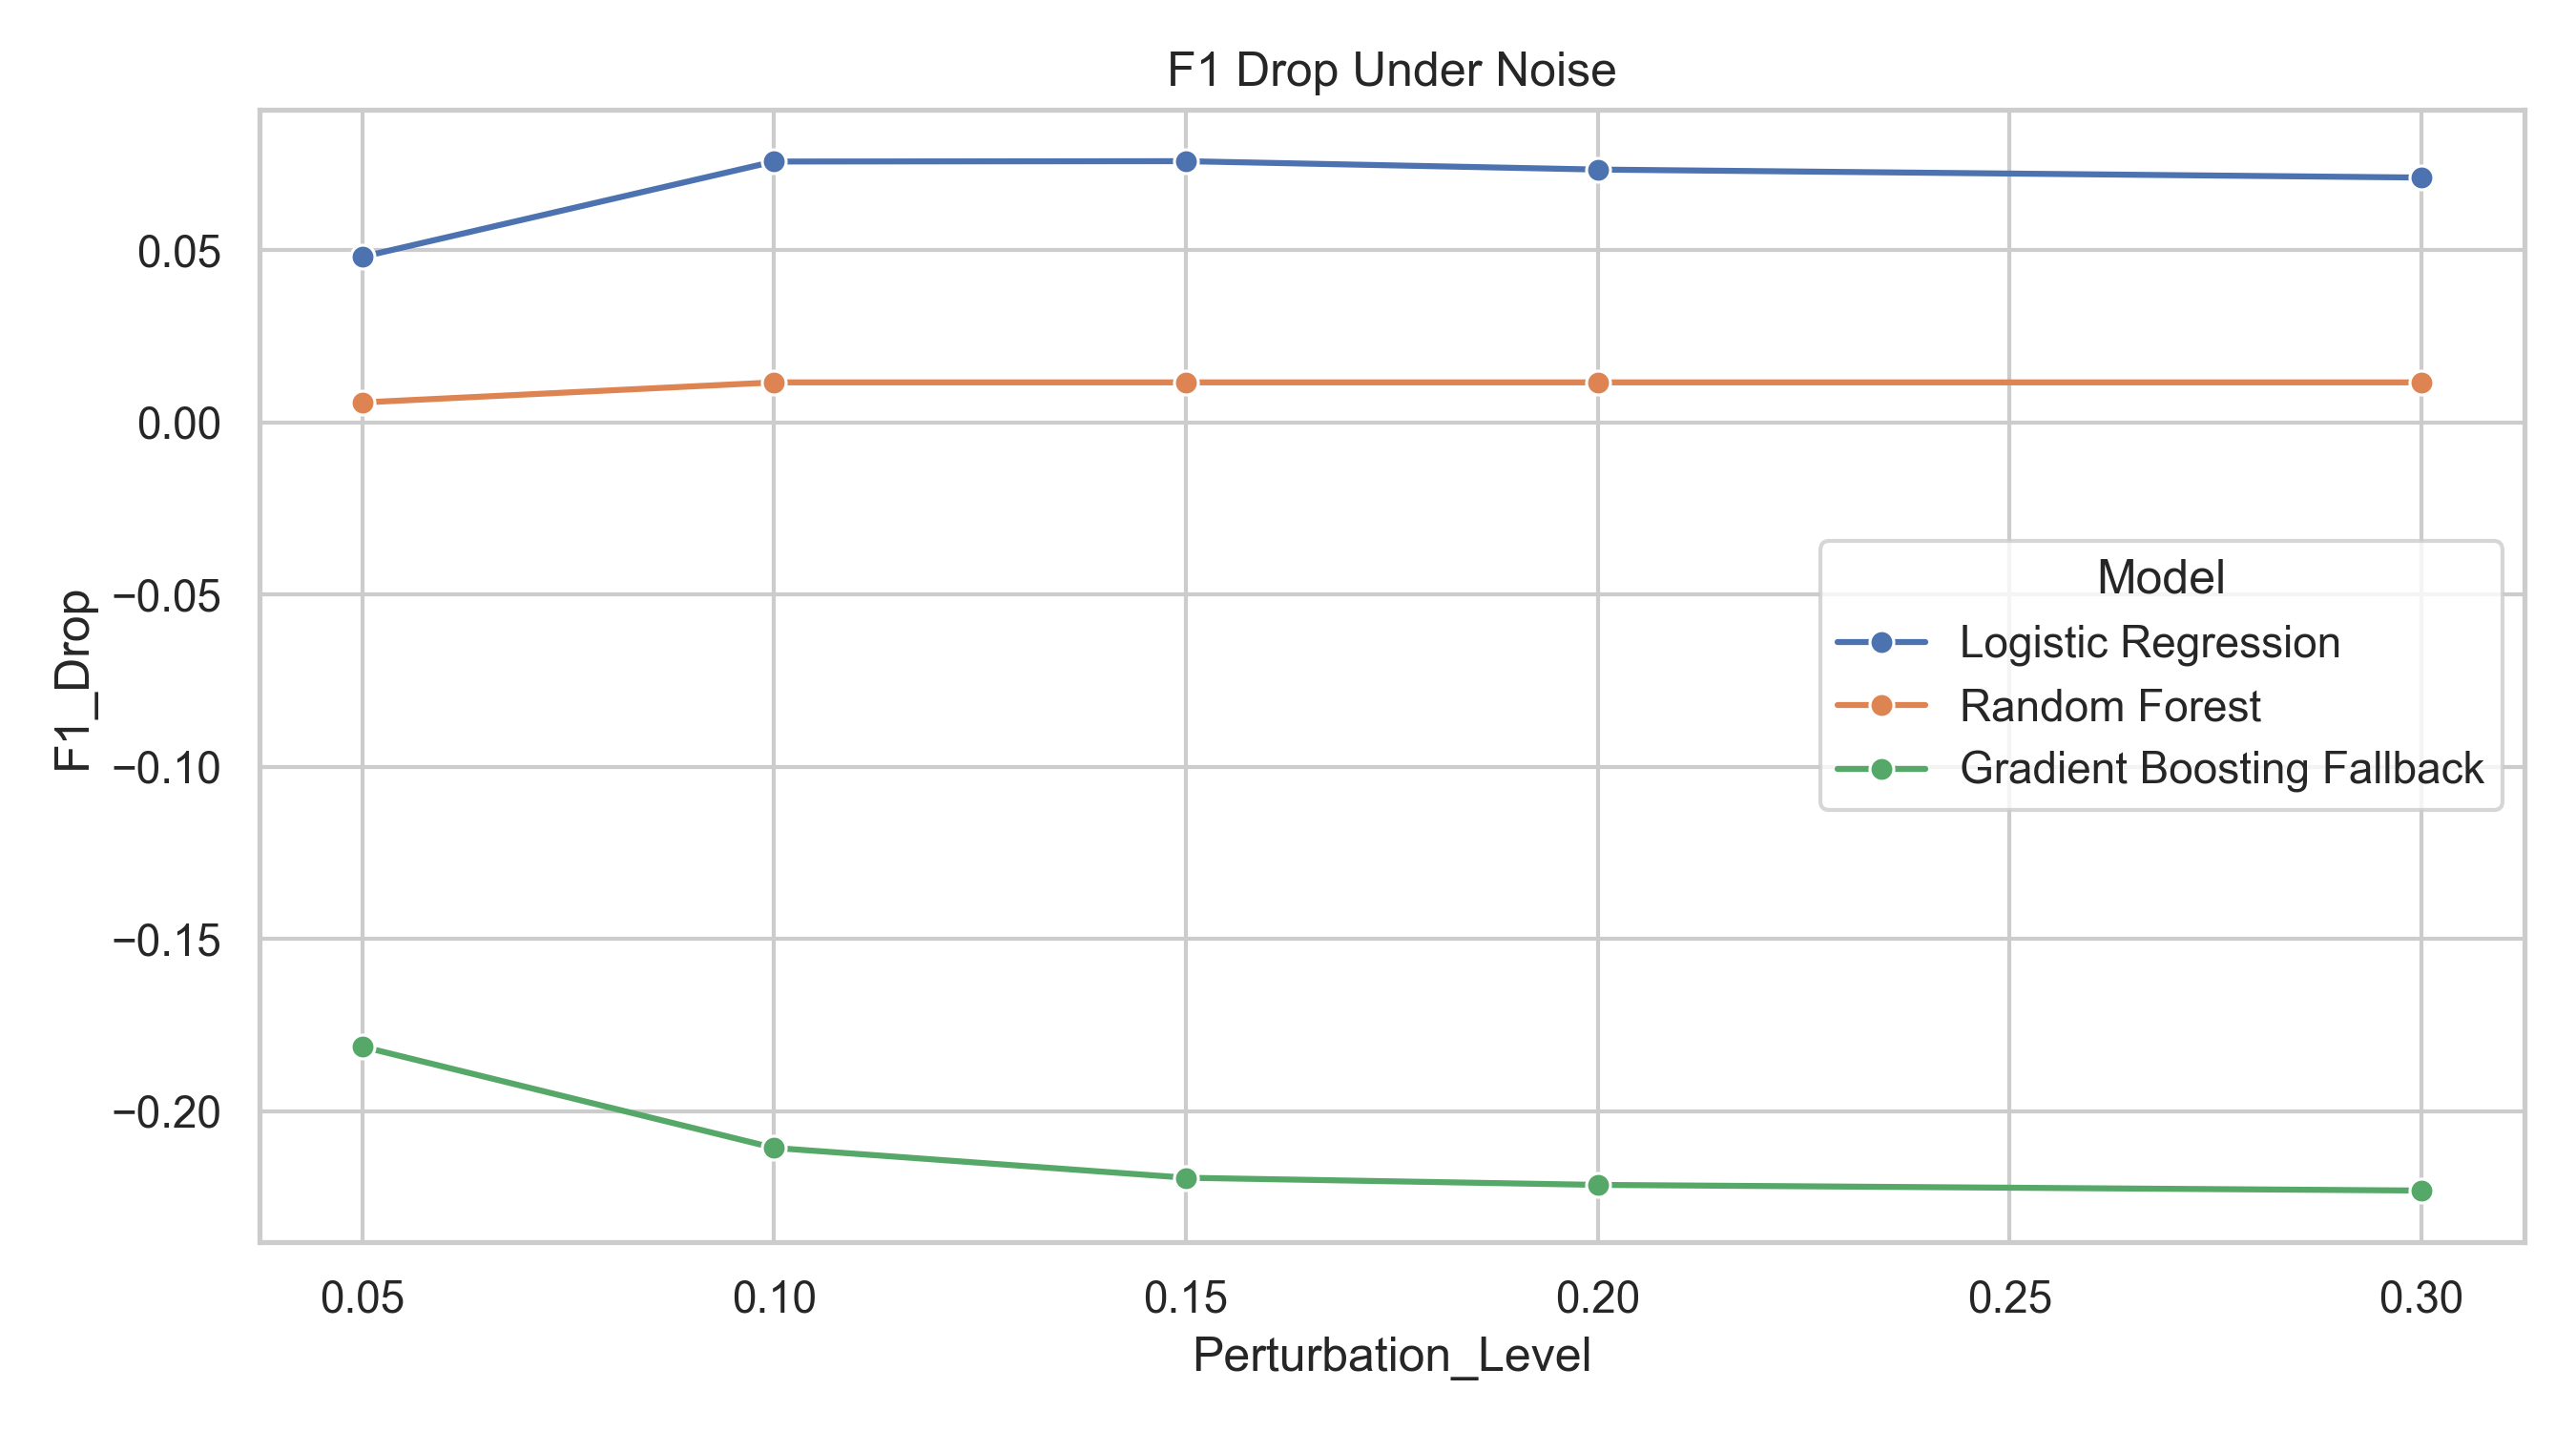

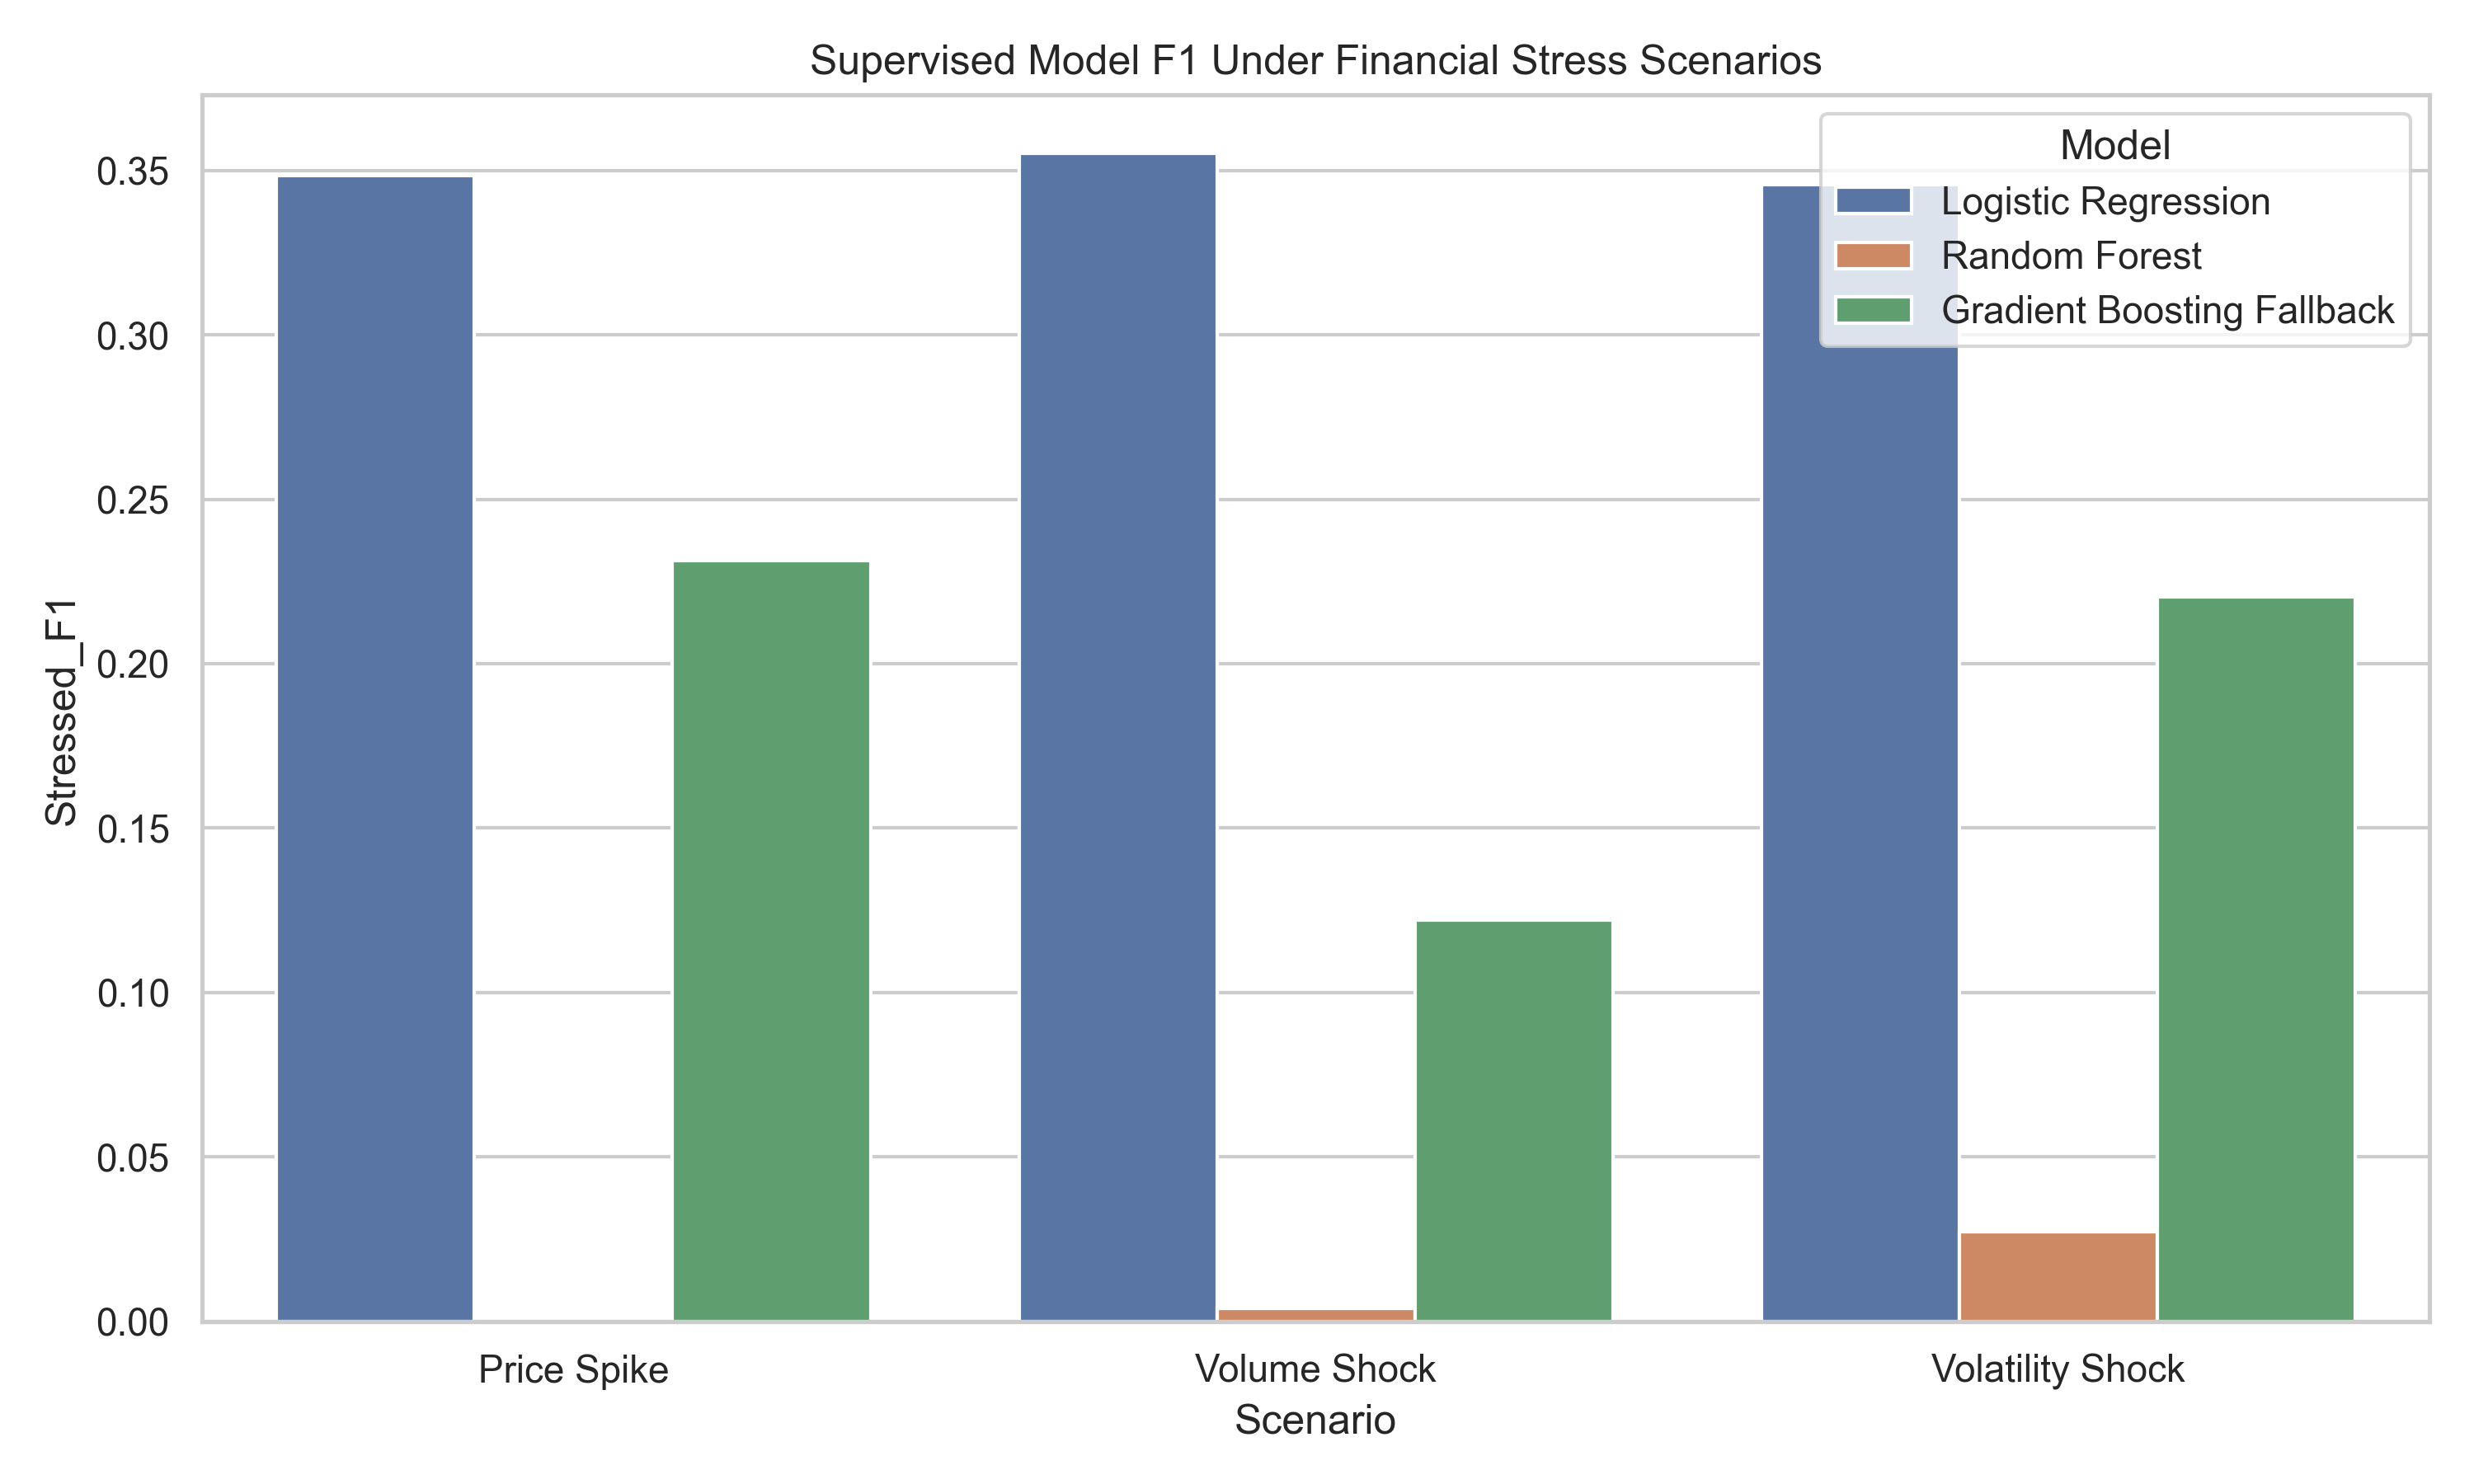

In [27]:
display(Image(filename=str(FIGURES / "supervised_f1_drop_under_noise.png")))
display(Image(filename=str(FIGURES / "supervised_stress_scenario_f1_comparison.png")))


## Explainability and drift


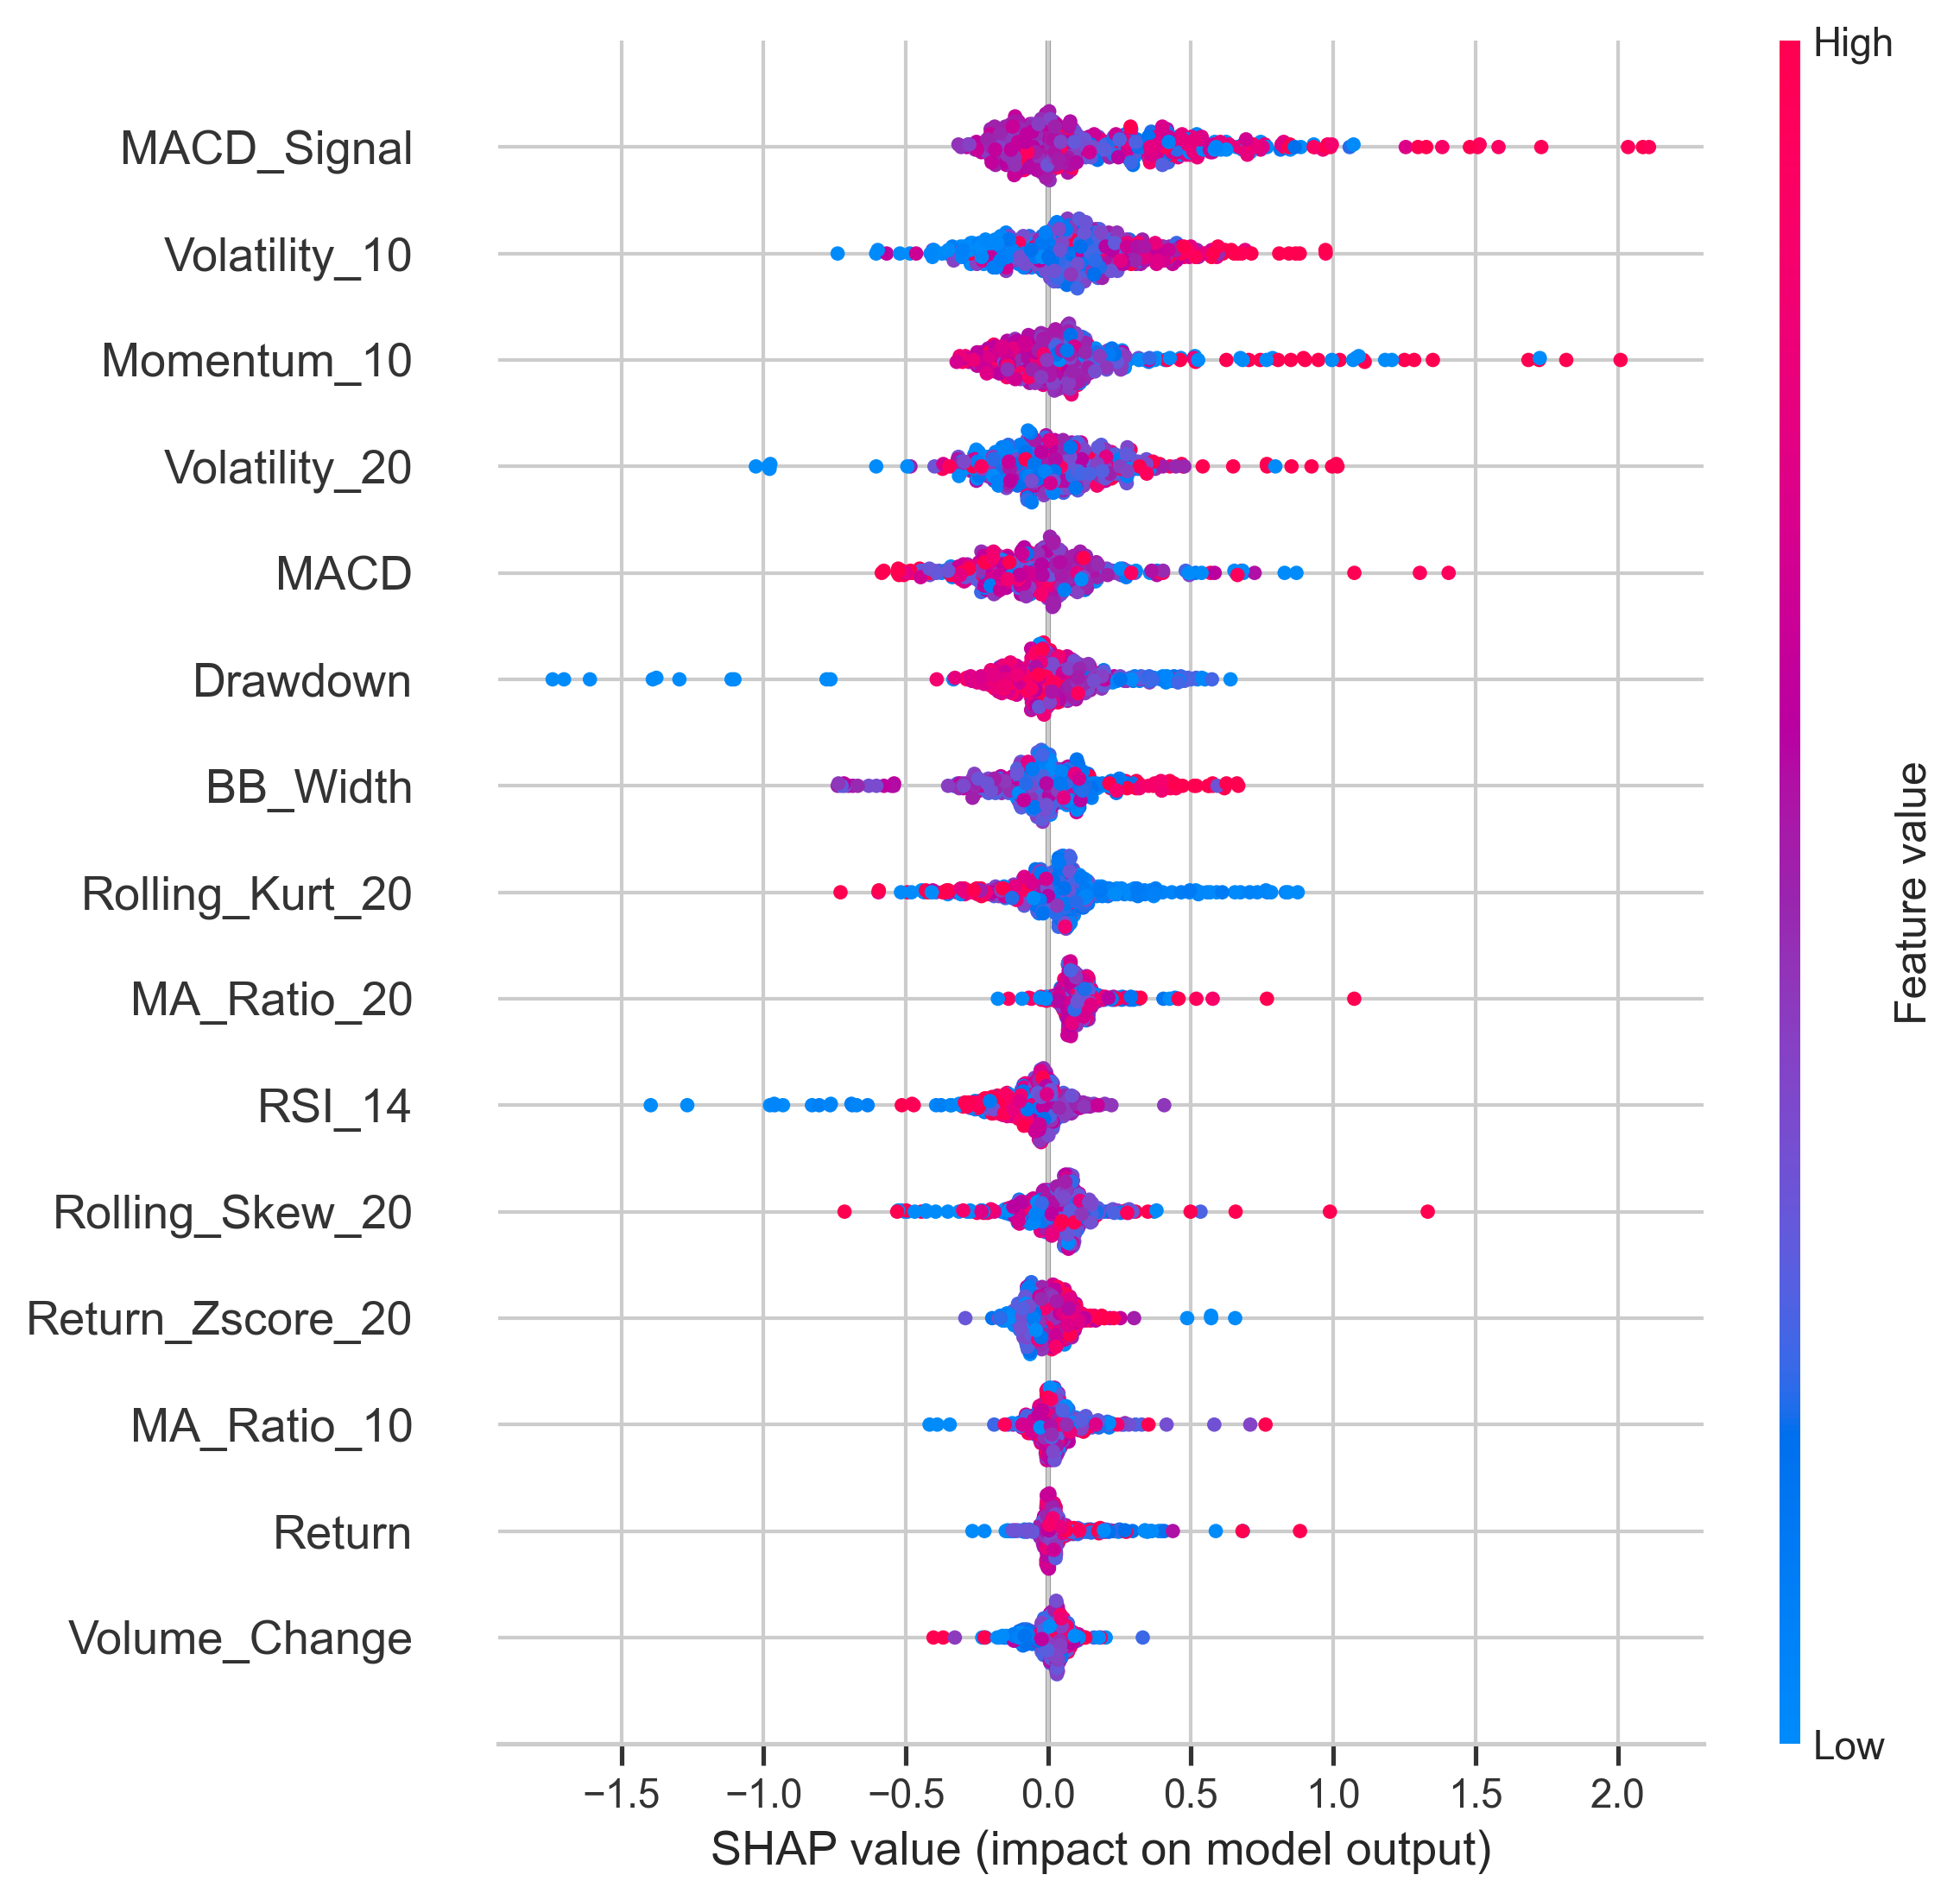

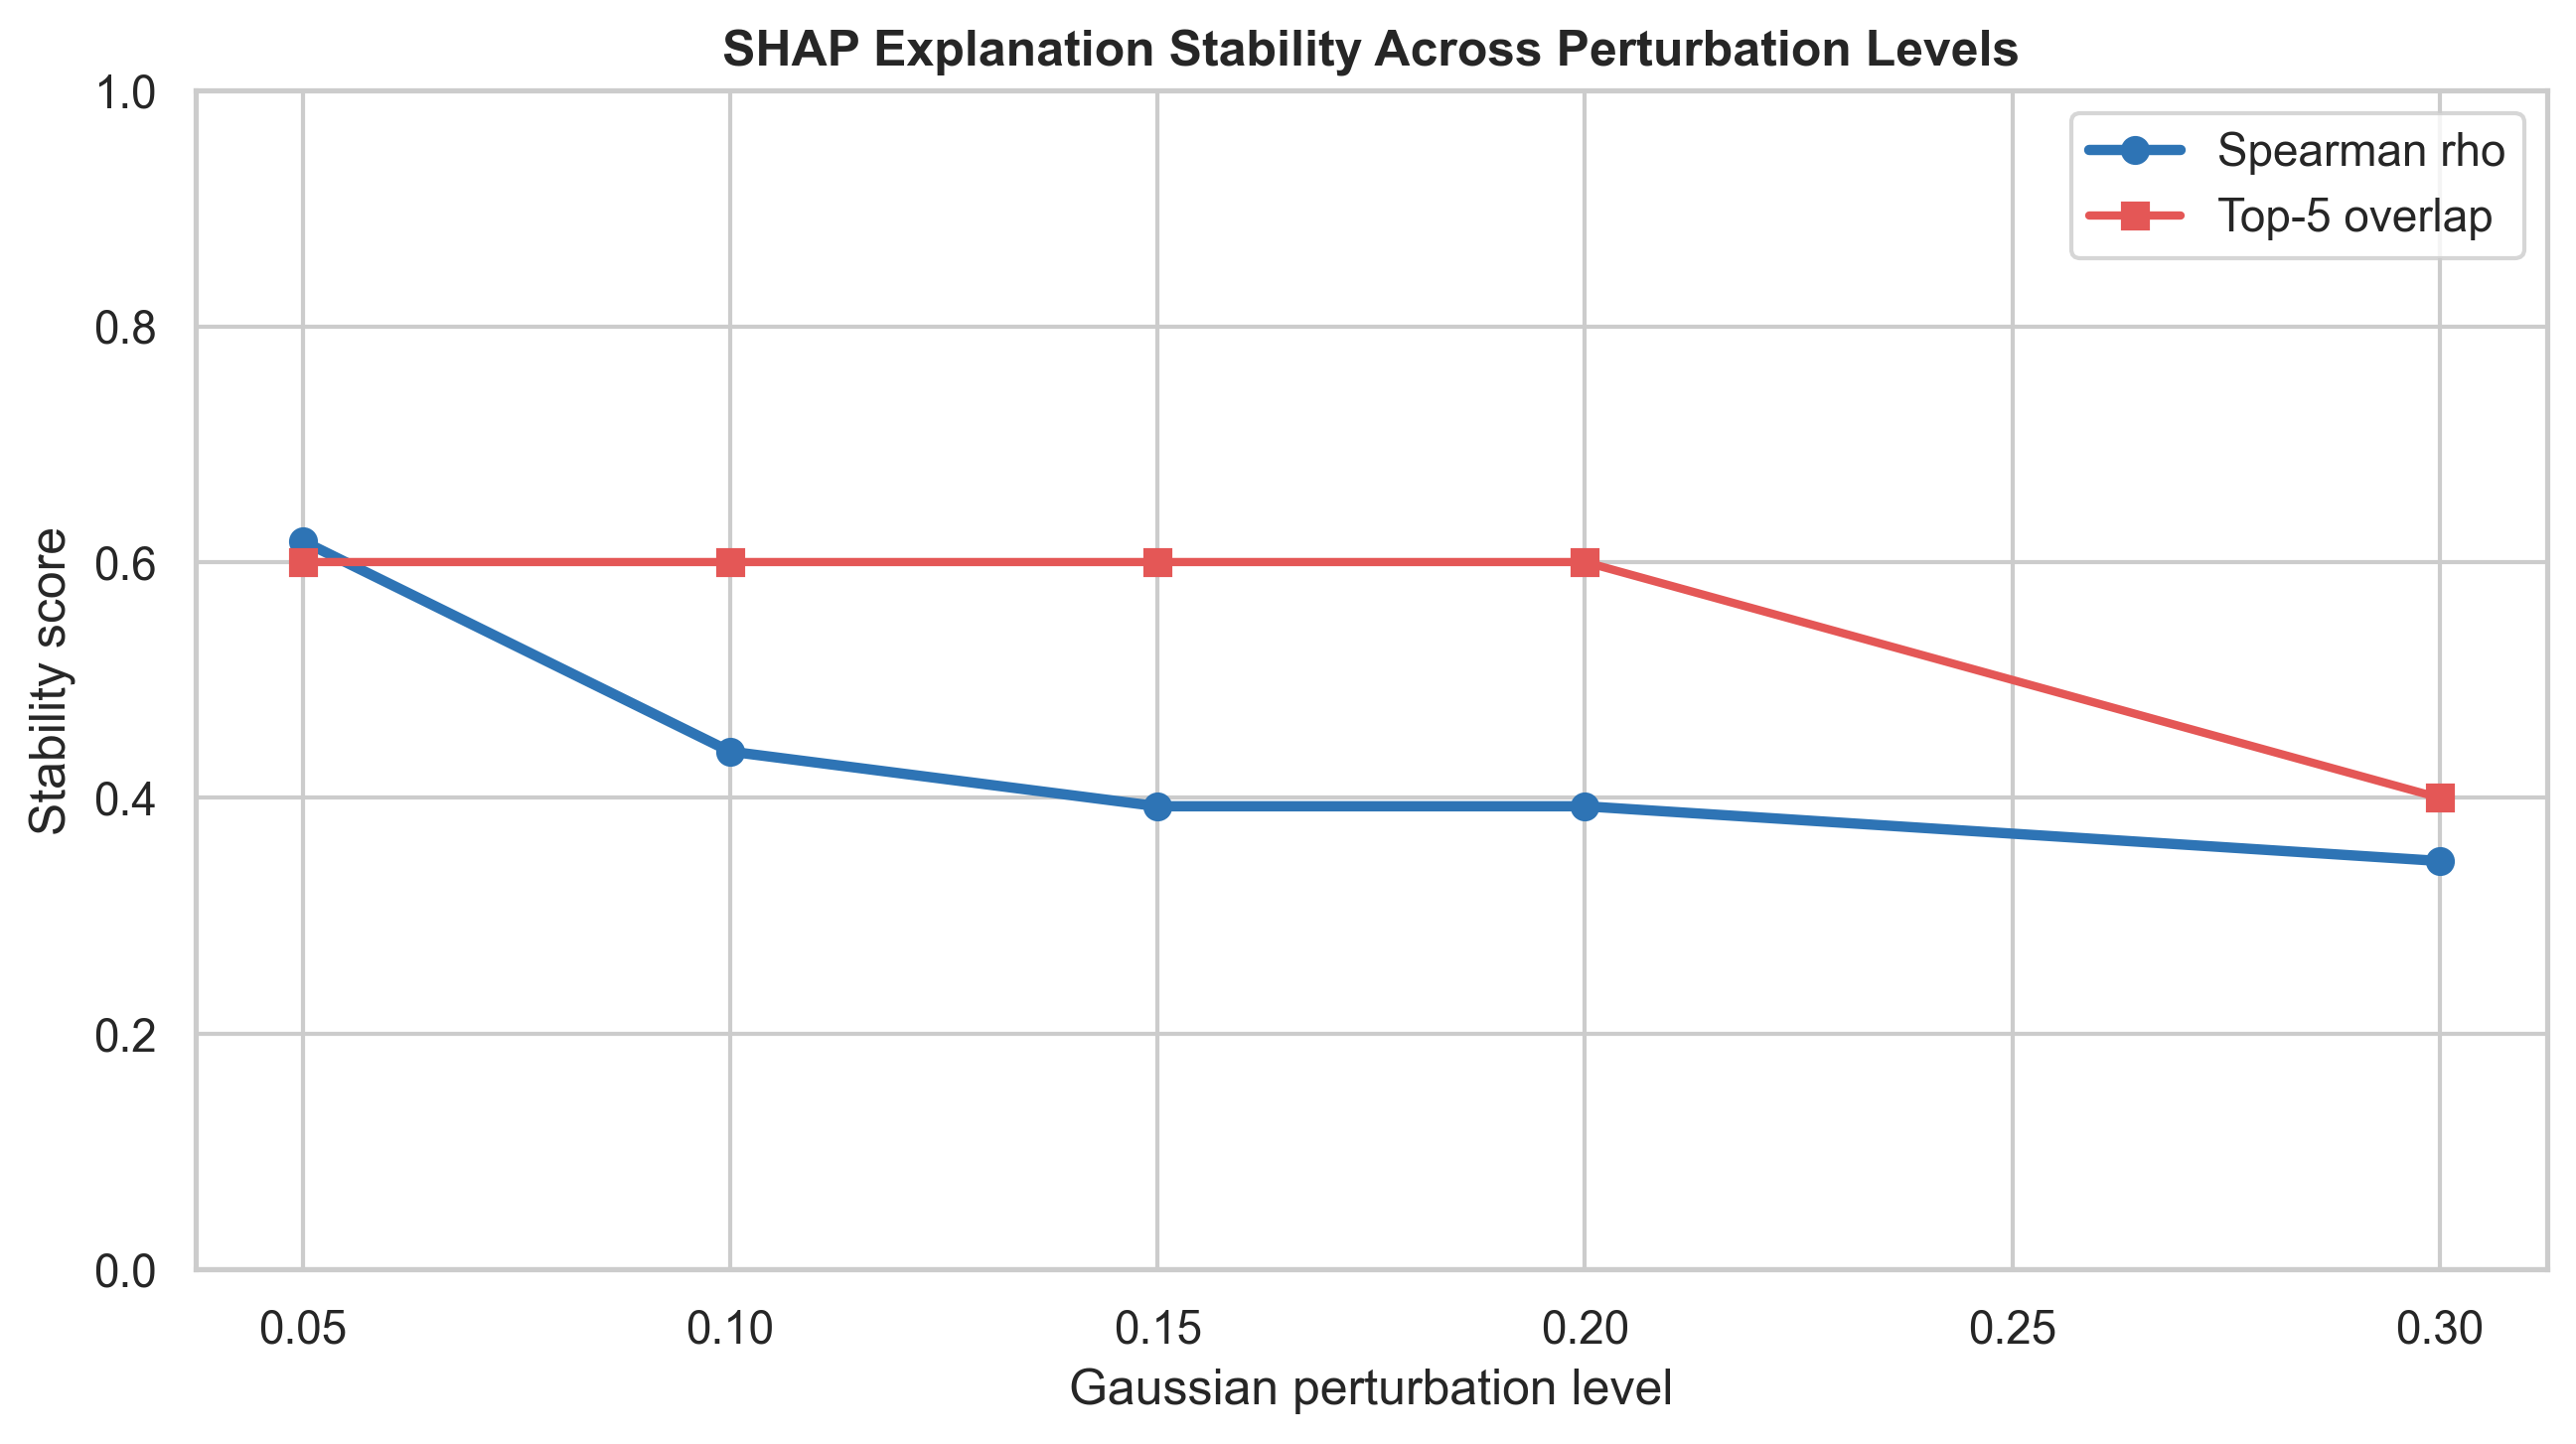

,Split,Window_Start,Window_End,Features_Checked,PSI_Alarms,KS_Alarms,Page_Hinkley_Alarms,CUSUM_Alarms,Retraining_Triggers
0,Test,2021-10-21,2022-01-20,15,7,12,15,6,15
1,Test,2022-01-21,2022-04-21,15,11,14,15,13,15
2,Test,2022-04-22,2022-07-22,15,13,14,15,12,15
3,Test,2022-07-25,2022-10-20,15,12,14,15,6,15
4,Test,2022-10-21,2023-01-23,15,10,12,15,11,15
5,Test,2023-01-24,2023-04-24,15,8,14,15,10,15
6,Test,2023-04-25,2023-07-25,15,5,11,14,9,15
7,Test,2023-07-26,2023-10-23,15,6,12,15,5,15


In [28]:
display(Image(filename=str(FIGURES / "shap_summary_plot_test_sample.png")))
display(Image(filename=str(FIG4 / "figure_4_18_shap_stability.png")))
pd.read_csv(RESULTS / "drift_alarm_summary.csv").head(8)


## Cybersecurity resilience


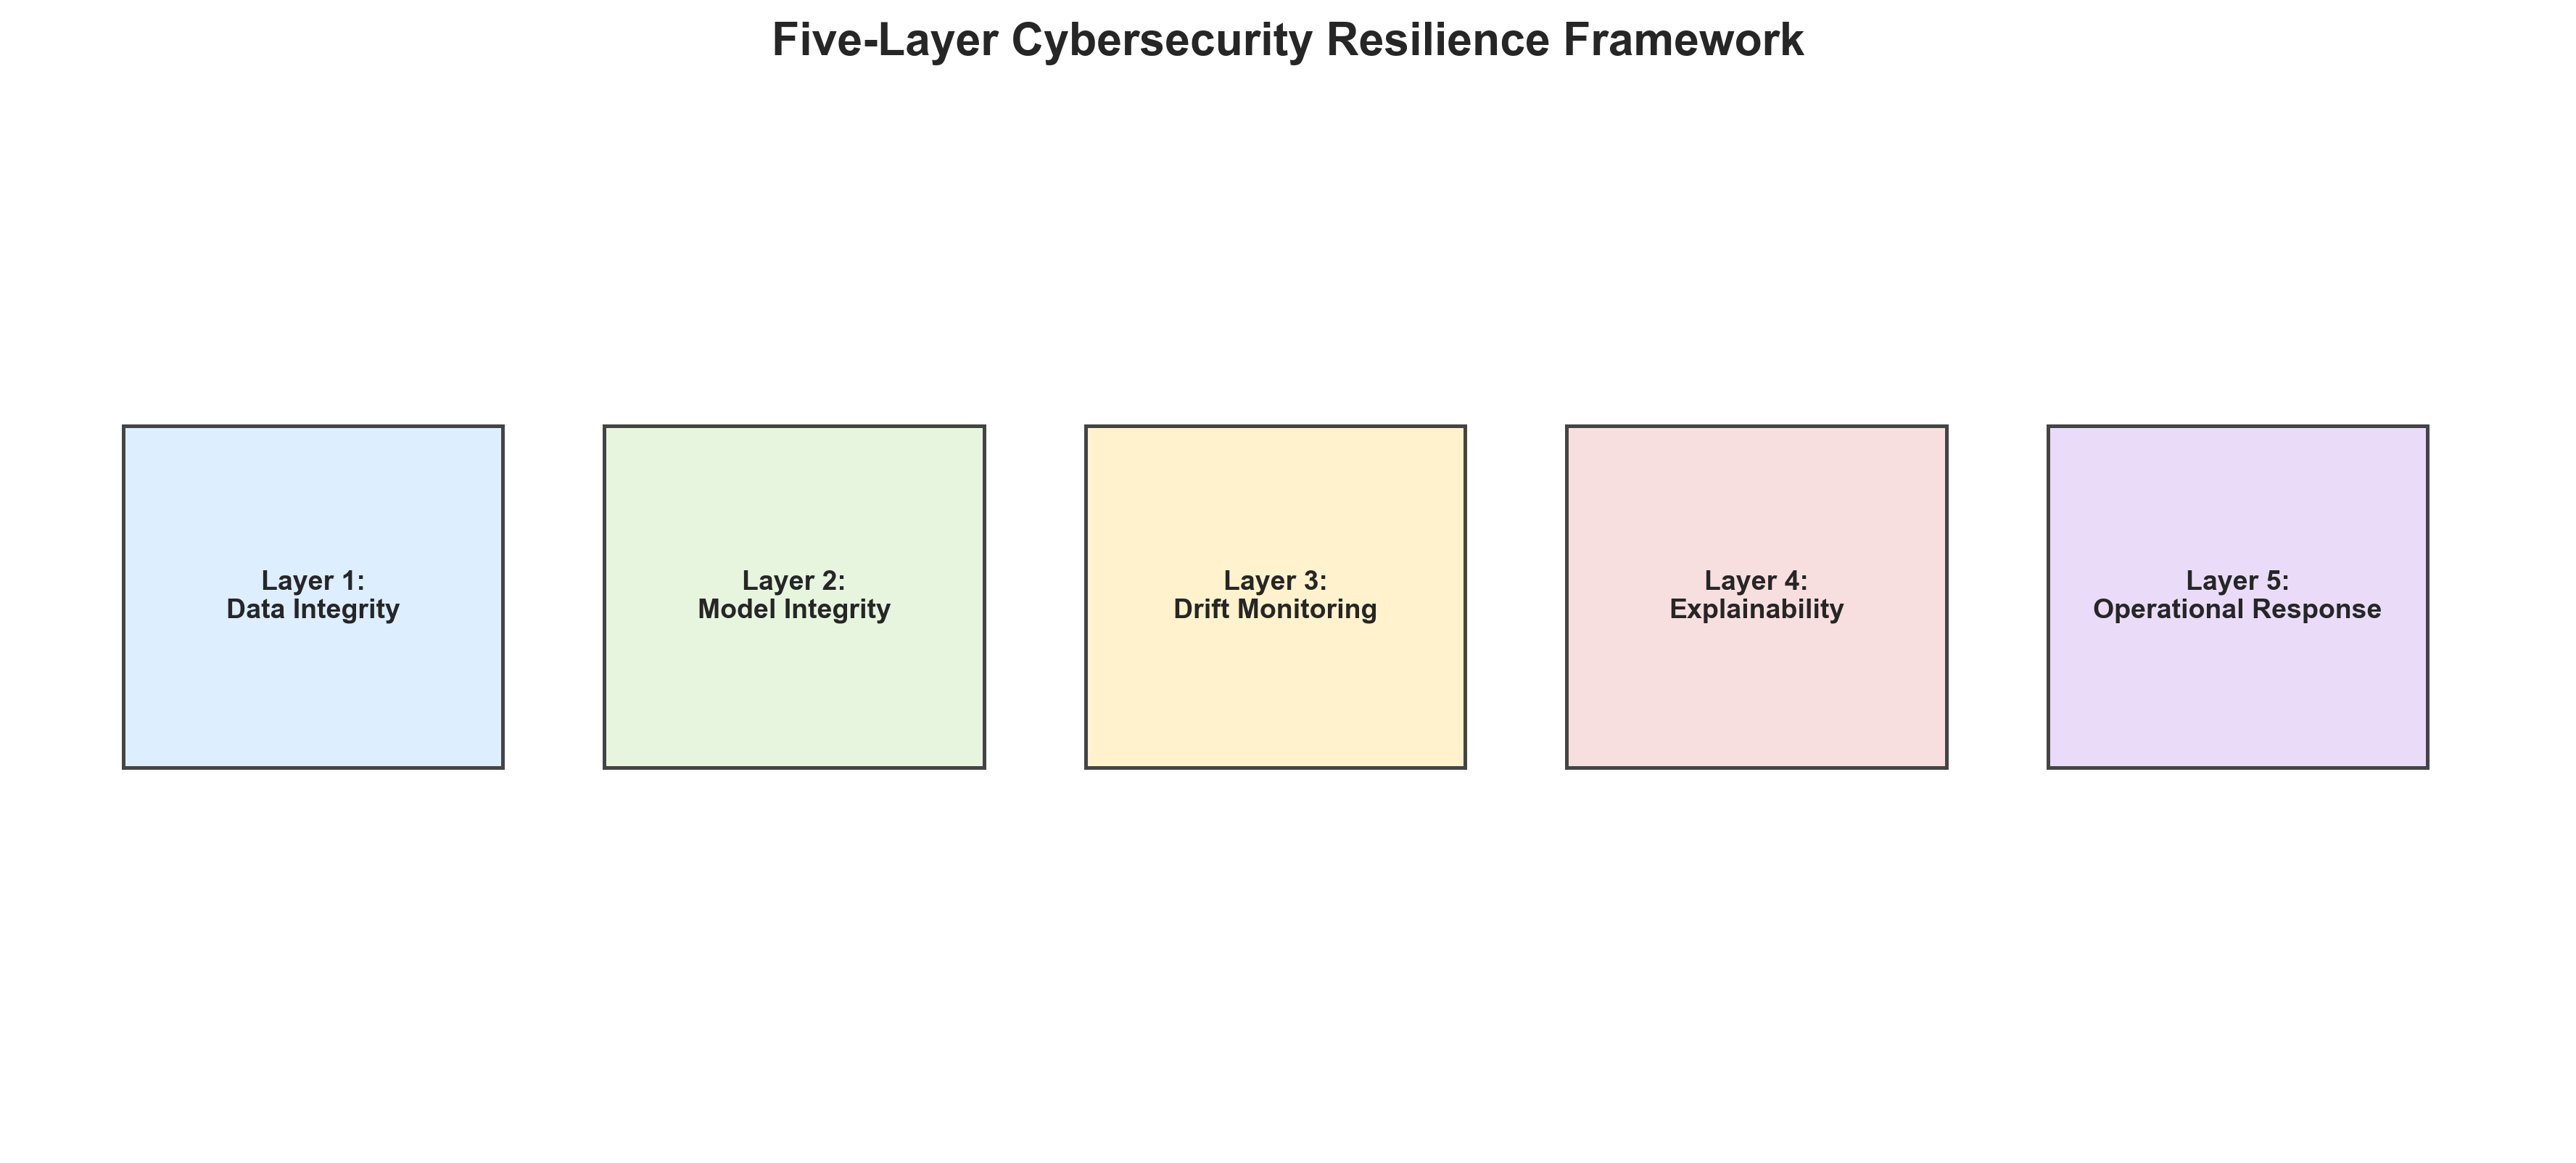

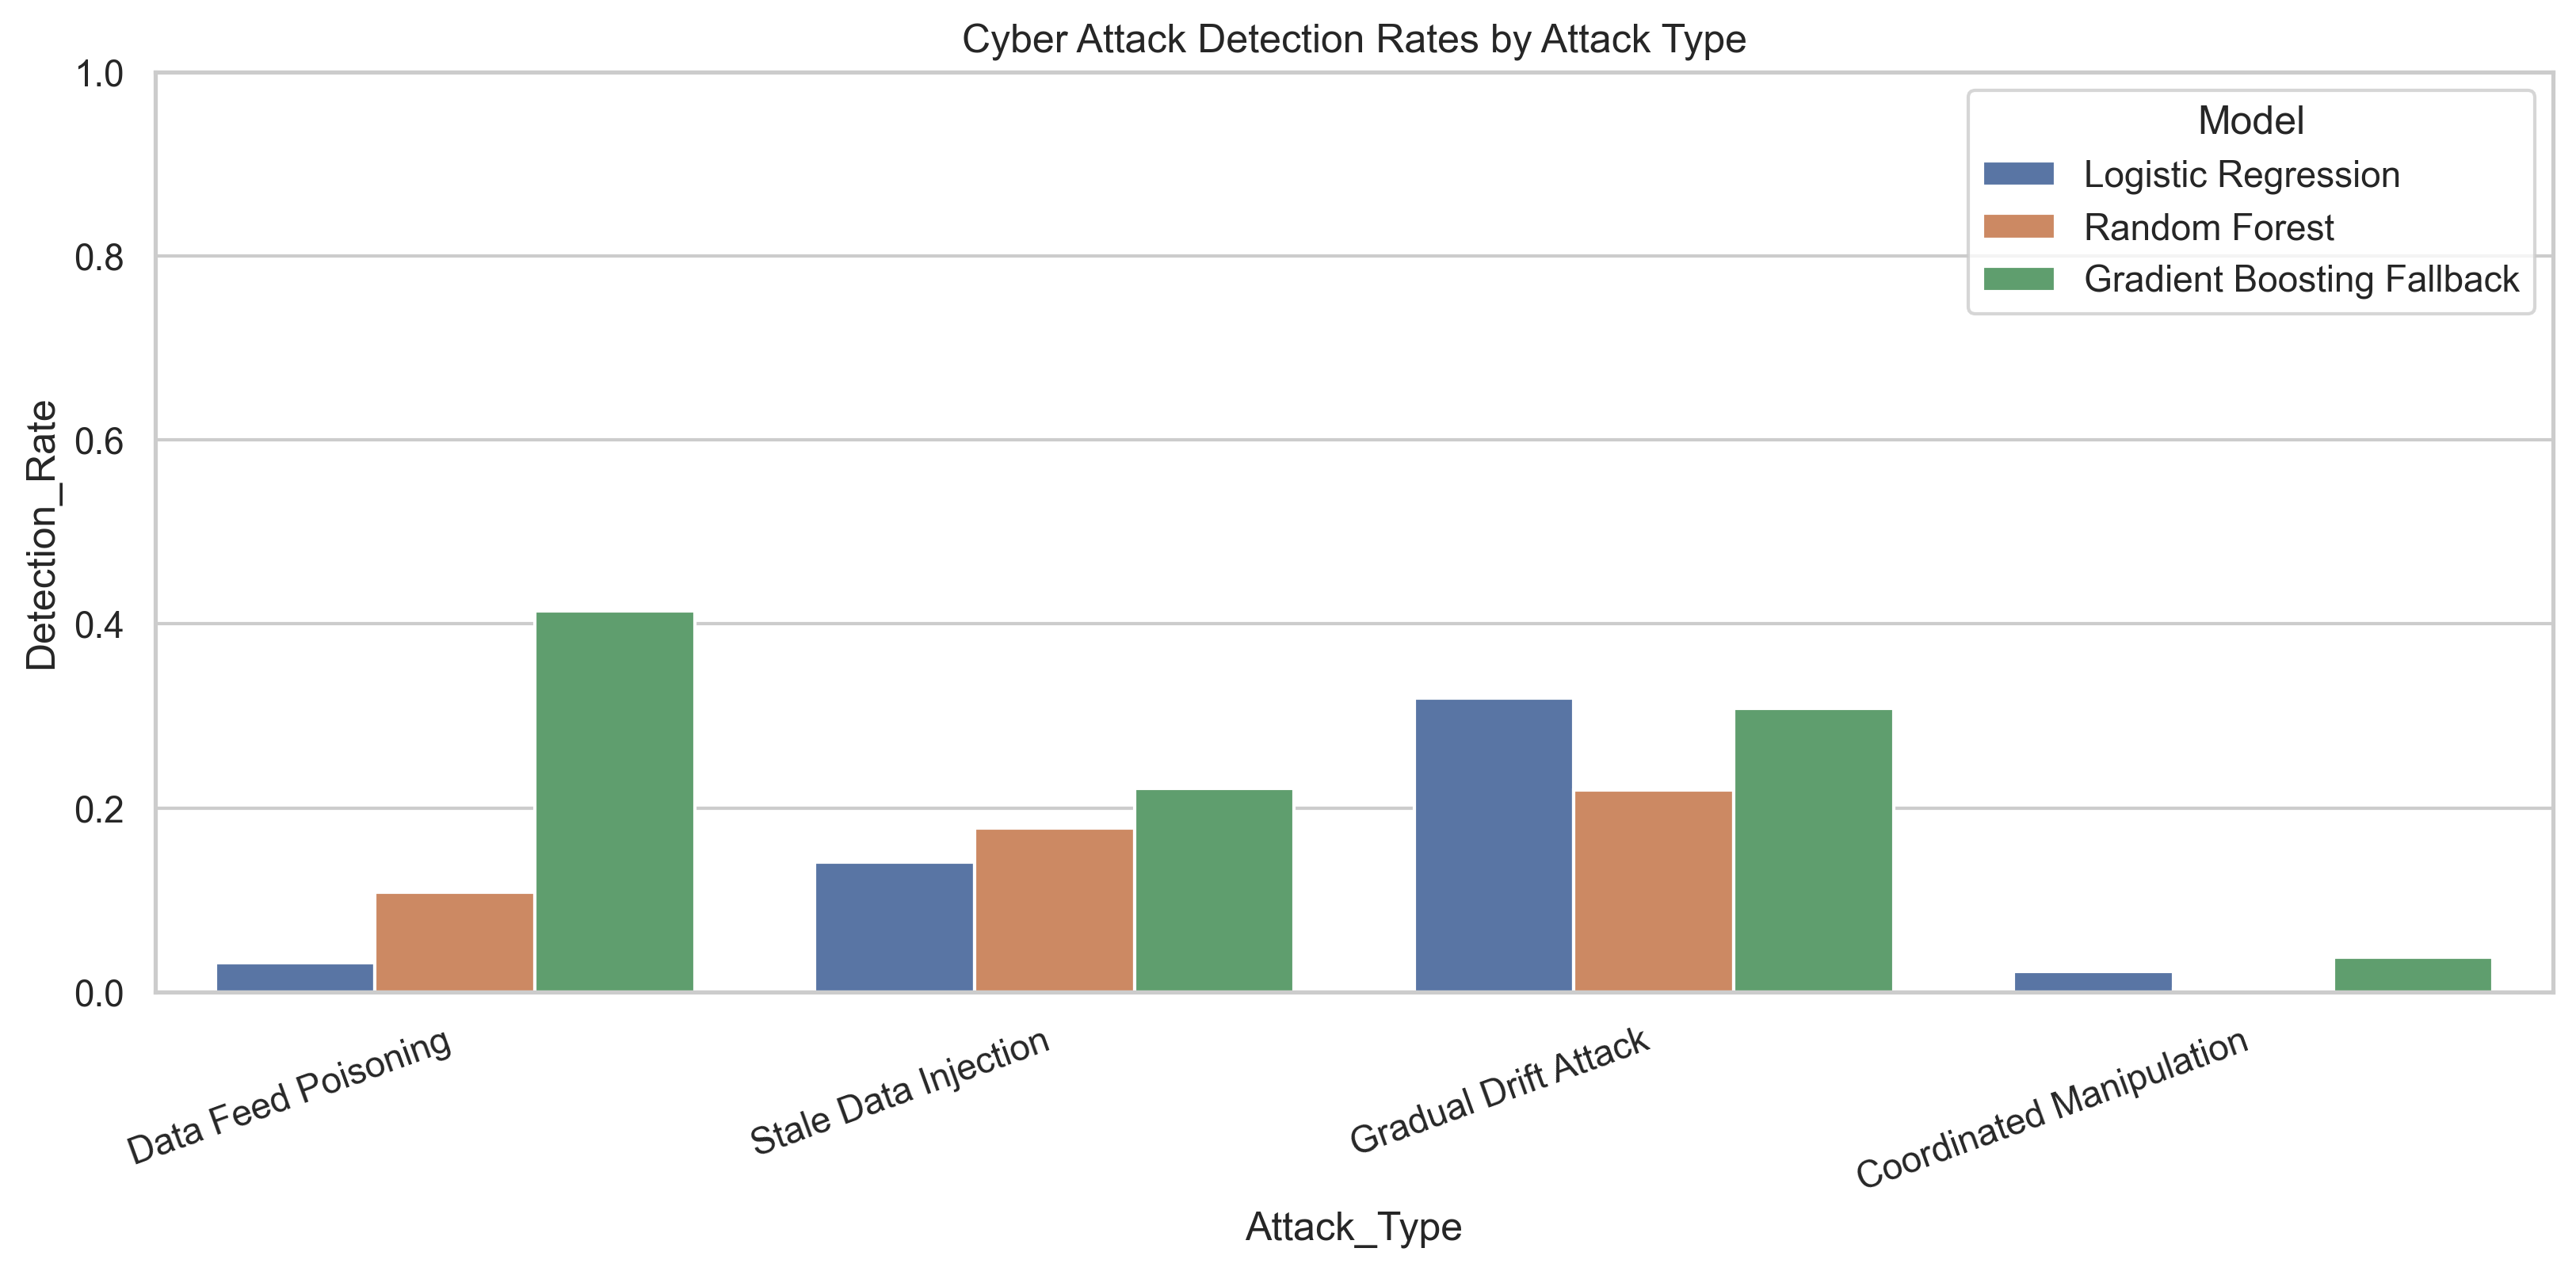

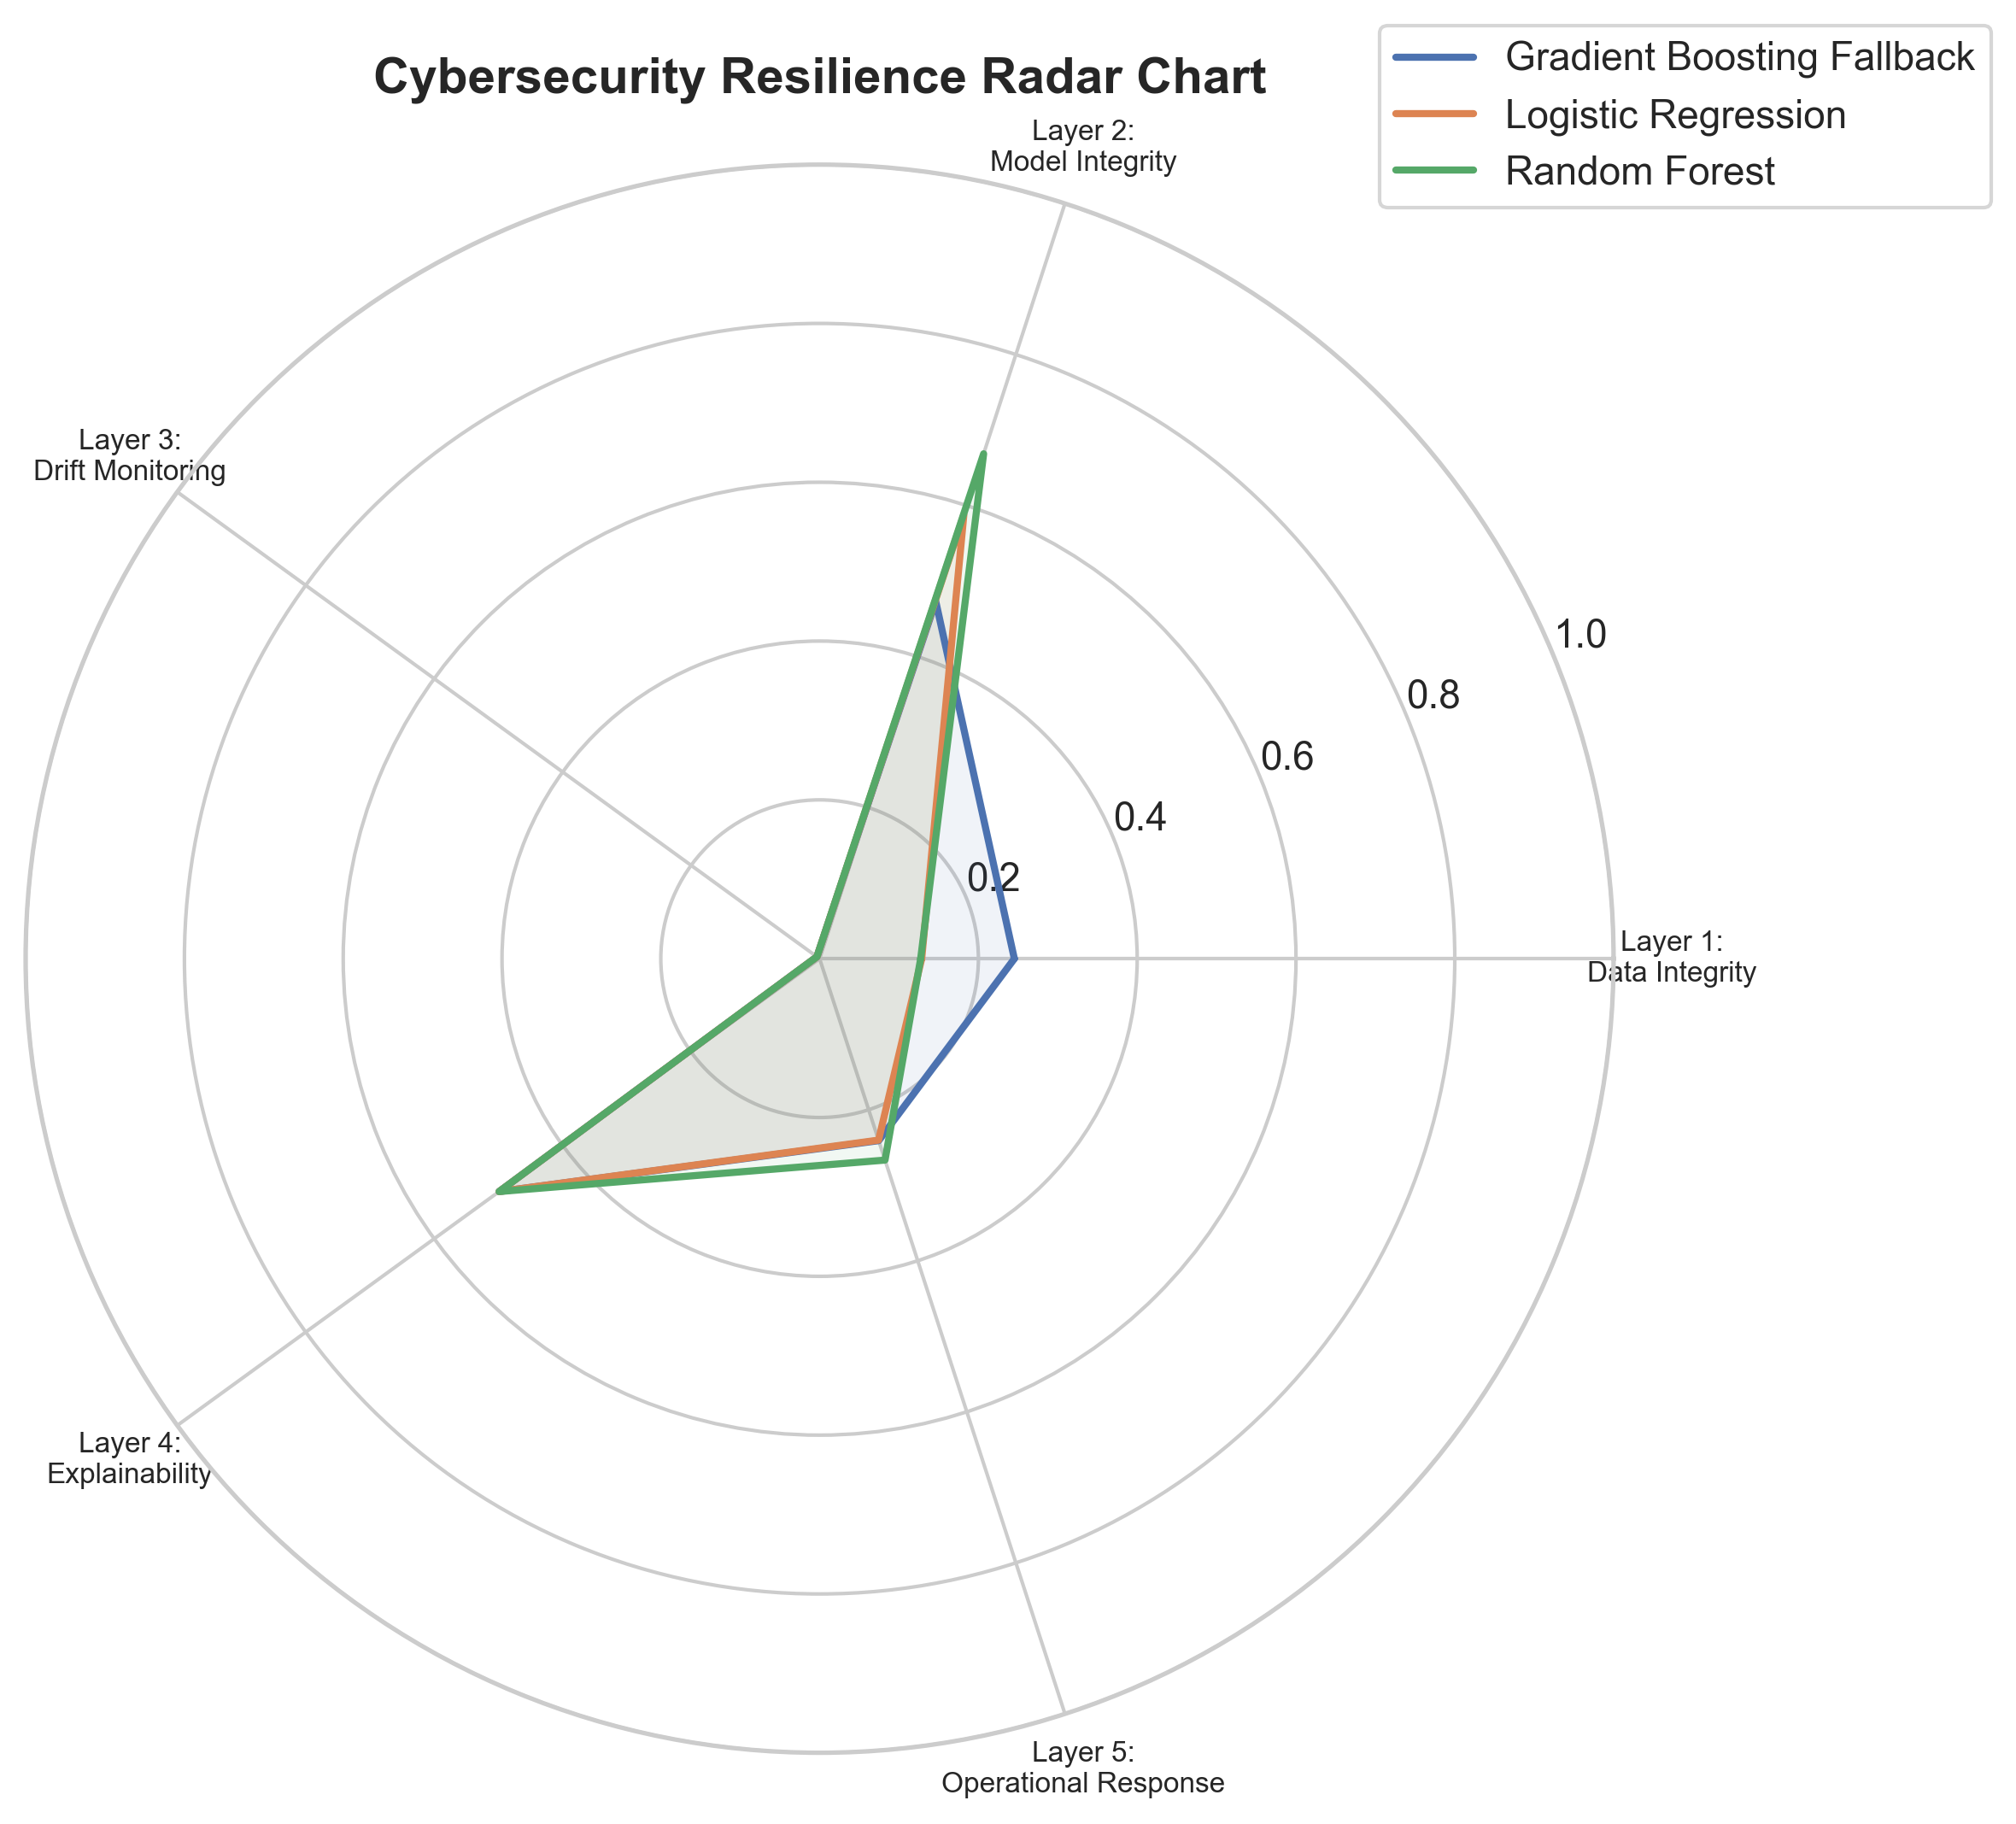

In [29]:
display(Image(filename=str(FIGURES / "layered_defence_framework_diagram.png")))
display(Image(filename=str(FIGURES / "cyber_attack_detection_rates_by_type.png")))
display(Image(filename=str(FIGURES / "cybersecurity_resilience_radar_chart.png")))


# Chapter 5: Discussion


In [30]:
pd.DataFrame([
    {"Research Question": "RQ1", "Answer": "Qualified yes", "Evidence": "Logistic Regression recall 0.745 and F1 0.358 on test data."},
    {"Research Question": "RQ2", "Answer": "Yes", "Evidence": "Fusion OR recall 0.957; consensus policy more balanced."},
    {"Research Question": "RQ3", "Answer": "Mixed", "Evidence": "Robustness, explainability, and usefulness diverged under disturbance."},
])


,Research Question,Answer,Evidence
0,RQ1,Qualified yes,Logistic Regression recall 0.745 and F1 0.358 ...
1,RQ2,Yes,Fusion OR recall 0.957; consensus policy more ...
2,RQ3,Mixed,"Robustness, explainability, and usefulness div..."


# Chapter 6: Conclusion

- The project built an integrated supervised financial-AI evaluation framework.
- Logistic Regression was the most operationally useful model despite lower accuracy.
- Alert fusion improved coverage, but precision remained a challenge.
- Robustness, explanation stability, drift, and cyber resilience must be evaluated together.
- The work is a functional prototype, not a production-ready deployment.
